<a href="https://colab.research.google.com/github/AdelZahid/Multimodal_Website_Cyber_security/blob/main/MultiModal_Website_CS_rs_057.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WebsiteDataset Processing, Feature Extraction, and EDA

This notebook handles the end-to-end extraction, validation, cleaning, and preparation of numerical features from raw HTML, text, and third-party JSON files. It does not perform any machine learning model training.

In [ ]:
# CELL 1 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# CELL 2 — Dataset Path and Configuration
from pathlib import Path

# User can manually paste their Google Drive path here
Dataset_PATH = "/content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset"

DATASET_DIR = Path(Dataset_PATH) if Dataset_PATH else Path("/content")

CSV_PATH = DATASET_DIR / "dataset.csv"

# Since html_file, text_file, and thirdparty_file columns in dataset.csv already contain
# the directory prefixes (e.g. 'html/000001.html'), we point these base directory paths
# directly to DATASET_DIR to avoid duplicate folders.
HTML_DIR = DATASET_DIR
TEXT_DIR = DATASET_DIR
THIRDPARTY_DIR = DATASET_DIR

OUTPUT_PATH = DATASET_DIR / "processed_features"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
(OUTPUT_PATH / "eda" / "html").mkdir(parents=True, exist_ok=True)
(OUTPUT_PATH / "eda" / "text").mkdir(parents=True, exist_ok=True)
(OUTPUT_PATH / "eda" / "thirdparty").mkdir(parents=True, exist_ok=True)

print(f"Dataset Directory: {DATASET_DIR}")
print(f"Outputs will be saved in: {OUTPUT_PATH}")

Dataset Directory: /content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset
Outputs will be saved in: /content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features


In [ ]:
import os
from pathlib import Path

# Diagnostics to check what files are present inside the Dataset directory
print(f"Checking contents of Dataset_PATH: {Dataset_PATH}")
base_path = Path(Dataset_PATH)
if base_path.exists():
    for item in base_path.iterdir():
        if item.is_dir():
            sub_items = list(item.glob('*'))
            print(f"Directory: {item.name} | Total items inside: {len(sub_items)}")
            if len(sub_items) > 0:
                print(f"  First 3 items: {[p.name for p in sub_items[:3]]}")
        else:
            print(f"File: {item.name}")
else:
    print("Dataset_PATH directory does not exist! Please ensure Drive is correctly mounted and path is correct.")

Checking contents of Dataset_PATH: /content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset
File: dataset.csv
Directory: thirdparty | Total items inside: 762
  First 3 items: ['000001.json', '000002.json', '000003.json']
Directory: html | Total items inside: 762
  First 3 items: ['000001.html', '000002.html', '000003.html']
Directory: text | Total items inside: 762
  First 3 items: ['000001.txt', '000002.txt', '000003.txt']
Directory: processed_features | Total items inside: 23
  First 3 items: ['eda', 'url_features.csv', 'html_validation_report.csv']


In [ ]:
# CELL 3 — Import Libraries
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import unicodedata
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# CELL 4 — Load and Inspect dataset.csv
try:
    df_csv = pd.read_csv(CSV_PATH)
    print("--- CSV Information ---")
    print(f"Shape: {df_csv.shape}")
    print(f"Columns: {list(df_csv.columns)}")
    print("\n--- Data Types ---")
    print(df_csv.dtypes)
    print("\n--- First 5 Rows ---")
    display(df_csv.head())
    print("\n--- Missing Values ---")
    print(df_csv.isnull().sum())
    print(f"\nDuplicate rows count: {df_csv.duplicated().sum()}")
except Exception as e:
    print(f"Could not load dataset.csv: {e}. Creating a dummy dataframe for testing...")
    # Fallback simulation
    df_csv = pd.DataFrame({
        'id': ['000001', '000002'],
        'html_file': ['000001.html', '000002.html'],
        'text_file': ['000001.txt', '000002.txt'],
        'thirdparty_file': ['000001.json', '000002.json'],
        'risk': [0, 1]
    })
    display(df_csv)

--- CSV Information ---
Shape: (762, 12)
Columns: ['id', 'url', 'final_url', 'http_status', 'html_file', 'text_file', 'thirdparty_file', 'risk', 'category', 'illicit_activity_type', 'text_length', 'collected_at']

--- Data Types ---
id                        int64
url                      object
final_url                object
http_status               int64
html_file                object
text_file                object
thirdparty_file          object
risk                     object
category                 object
illicit_activity_type    object
text_length               int64
collected_at             object
dtype: object

--- First 5 Rows ---


,id,url,final_url,http_status,html_file,text_file,thirdparty_file,risk,category,illicit_activity_type,text_length,collected_at
0,1,http://www.teramill.com/,http://www.teramill.com/,200,html/000001.html,text/000001.txt,thirdparty/000001.json,High,Scam,Suspicious,2416,9/24/2026
1,2,http://www.f0519141.xsph.ru/,http://www.f0519141.xsph.ru/,200,html/000002.html,text/000002.txt,thirdparty/000002.json,High,Scam,Suspicious,1728,9/24/2026
2,3,http://www.shprakserf.gq/,http://www.shprakserf.gq/,200,html/000003.html,text/000003.txt,thirdparty/000003.json,High,Scam,Suspicious,1765,9/24/2026
3,4,https://service-mitld.firebaseapp.com/,https://service-mitld.firebaseapp.com/,200,html/000004.html,text/000004.txt,thirdparty/000004.json,Safe,Business,Legitimate,205,9/24/2026
4,5,http://www.kuradox92.lima-city.de/,http://www.kuradox92.lima-city.de/,200,html/000005.html,text/000005.txt,thirdparty/000005.json,Moderate,Tech,Suspicious,183,9/24/2026



--- Missing Values ---
id                       0
url                      0
final_url                0
http_status              0
html_file                0
text_file                0
thirdparty_file          0
risk                     0
category                 0
illicit_activity_type    0
text_length              0
collected_at             0
dtype: int64

Duplicate rows count: 0


In [ ]:
# ================================================================
# URL ANALYSIS & FEATURE EXTRACTION
# ================================================================
import re
from urllib.parse import urlparse, parse_qs
from pathlib import Path
import ipaddress

# ------------------------------------------------
# 1. Paths
# ------------------------------------------------

PROCESSED_DIR = DATASET_DIR / "processed_features"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

URL_FEATURES_PATH = PROCESSED_DIR / "url_features.csv"

# ------------------------------------------------
# 2. Load dataset
# ------------------------------------------------

df_url = pd.read_csv(CSV_PATH)

print("Dataset shape:", df_url.shape)
print("Columns:")
print(df_url.columns.tolist())

# ------------------------------------------------
# 3. Check URL column
# ------------------------------------------------

if "url" not in df_url.columns:
    raise ValueError(
        "The dataset does not contain a 'url' column."
    )

print("\nMissing URLs:", df_url["url"].isna().sum())

# ------------------------------------------------
# 4. Suspicious URL keywords
# ------------------------------------------------
# These are lexical indicators only.
# They do NOT automatically mean that a website is malicious.
# ------------------------------------------------

SUSPICIOUS_KEYWORDS = [
    "login",
    "signin",
    "sign-in",
    "verify",
    "verification",
    "account",
    "secure",
    "security",
    "update",
    "confirm",
    "confirmation",
    "password",
    "credential",
    "wallet",
    "bank",
    "banking",
    "paypal",
    "payment",
    "invoice",
    "bonus",
    "free",
    "reward",
    "prize",
    "claim",
    "urgent",
    "alert",
    "suspended",
    "unlock",
    "limited",
    "crypto",
    "bitcoin",
    "download"
]

# ------------------------------------------------
# 5. Helper functions
# ------------------------------------------------

def safe_url(url):
    """
    Convert URL to a clean string.
    """
    if pd.isna(url):
        return ""

    url = str(url).strip()

    if not url:
        return ""

    if not re.match(r"^[a-zA-Z][a-zA-Z0-9+.-]*://", url):
        url = "http://" + url

    return url


def get_hostname(parsed):
    """
    Safely extract hostname.
    """
    try:
        return parsed.hostname or ""
    except Exception:
        return ""


def is_ip_address(hostname):
    """
    Check whether hostname is an IPv4 or IPv6 address.
    """
    if not hostname:
        return 0

    try:
        ipaddress.ip_address(hostname)
        return 1
    except ValueError:
        return 0


def count_special_characters(url):
    """
    Count characters that are neither:
    - letters
    - digits
    - whitespace
    - common URL structural characters

    Structural URL characters excluded:
    . - / ? = & : _ %
    """
    return len(
        re.findall(
            r"[^a-zA-Z0-9\s.\-/?=&:_%]",
            url
        )
    )


def count_subdirectories(path):
    """
    Count path directories.

    Example:
        /account/login/reset
        -> 2 subdirectories

    Empty path:
        -> 0
    """
    if not path or path == "/":
        return 0

    parts = [
        p for p in path.split("/")
        if p
    ]

    # Number of separators between path components
    return max(len(parts) - 1, 0)


def has_suspicious_keyword(url):
    """
    Check whether any predefined suspicious keyword
    occurs in the URL.

    Returns:
        1 = keyword found
        0 = no keyword found
    """
    url_lower = url.lower()

    for keyword in SUSPICIOUS_KEYWORDS:
        if keyword in url_lower:
            return 1

    return 0


def extract_tld(hostname):
    """
    Extract the apparent top-level domain.

    Examples:
        example.com       -> com
        example.org       -> org
        example.co.uk    -> uk
        localhost         -> ""
        192.168.1.1       -> ""
    """
    if not hostname:
        return ""

    hostname = hostname.lower().strip(".")

    if is_ip_address(hostname):
        return ""

    parts = hostname.split(".")

    if len(parts) < 2:
        return ""

    return parts[-1]


# ------------------------------------------------
# 6. URL feature extraction
# ------------------------------------------------

def extract_url_features(url):

    original_url = "" if pd.isna(url) else str(url).strip()

    parsed_url = safe_url(original_url)

    try:
        parsed = urlparse(parsed_url)
    except Exception:
        parsed = urlparse("")

    hostname = get_hostname(parsed)

    # -----------------------------
    # Basic URL lengths
    # -----------------------------

    url_length = len(original_url)

    url_hostname_length = len(hostname)

    url_path_length = len(parsed.path or "")

    url_query_length = len(parsed.query or "")

    url_fragment_length = len(parsed.fragment or "")

    # -----------------------------
    # Character-based features
    # -----------------------------

    url_number_of_dots = original_url.count(".")

    url_number_of_hyphens = original_url.count("-")

    url_number_of_digits = sum(
        char.isdigit()
        for char in original_url
    )

    url_number_of_special_characters = (
        count_special_characters(original_url)
    )

    url_number_of_slashes = original_url.count("/")

    # -----------------------------
    # Structural features
    # -----------------------------

    url_number_of_subdirectories = count_subdirectories(
        parsed.path
    )

    # Query parameters
    try:
        parameters = parse_qs(
            parsed.query,
            keep_blank_values=True
        )

        url_number_of_parameters = len(parameters)

    except Exception:
        url_number_of_parameters = 0

    # -----------------------------
    # Boolean URL indicators
    # -----------------------------

    url_has_ip_address = is_ip_address(hostname)

    url_has_https = (
        1 if parsed.scheme.lower() == "https" else 0
    )

    url_has_at_symbol = (
        1 if "@" in original_url else 0
    )

    url_has_dash = (
        1 if "-" in hostname else 0
    )

    url_has_suspicious_keyword = (
        has_suspicious_keyword(original_url)
    )

    # -----------------------------
    # TLD
    # -----------------------------

    url_tld = extract_tld(hostname)

    # -----------------------------
    # Return feature dictionary
    # -----------------------------

    return {
        "url_length": url_length,
        "url_hostname_length": url_hostname_length,
        "url_path_length": url_path_length,
        "url_query_length": url_query_length,
        "url_fragment_length": url_fragment_length,
        "url_number_of_dots": url_number_of_dots,
        "url_number_of_hyphens": url_number_of_hyphens,
        "url_number_of_digits": url_number_of_digits,
        "url_number_of_special_characters": url_number_of_special_characters,
        "url_number_of_slashes": url_number_of_slashes,
        "url_number_of_subdirectories": url_number_of_subdirectories,
        "url_number_of_parameters": url_number_of_parameters,
        "url_has_ip_address": url_has_ip_address,
        "url_has_https": url_has_https,
        "url_has_at_symbol": url_has_at_symbol,
        "url_has_dash": url_has_dash,
        "url_has_suspicious_keyword": url_has_suspicious_keyword,
        "url_tld": url_tld
    }


# ------------------------------------------------
# 7. Extract features for every URL
# ------------------------------------------------

url_feature_records = []

for _, row in df_url.iterrows():

    features = extract_url_features(row["url"])

    # Keep ID for safe future merging
    features["id"] = row["id"]

    url_feature_records.append(features)


url_features_df = pd.DataFrame(url_feature_records)

# ------------------------------------------------
# 8. Arrange columns
# ------------------------------------------------

url_feature_columns = [
    "id",
    "url_length",
    "url_hostname_length",
    "url_path_length",
    "url_query_length",
    "url_fragment_length",
    "url_number_of_dots",
    "url_number_of_hyphens",
    "url_number_of_digits",
    "url_number_of_special_characters",
    "url_number_of_slashes",
    "url_number_of_subdirectories",
    "url_number_of_parameters",
    "url_has_ip_address",
    "url_has_https",
    "url_has_at_symbol",
    "url_has_dash",
    "url_has_suspicious_keyword",
    "url_tld"
]

url_features_df = url_features_df[
    url_feature_columns
]

# ------------------------------------------------
# 9. Check duplicate IDs
# ------------------------------------------------

duplicate_ids = url_features_df["id"].duplicated().sum()

print("\nDuplicate IDs:", duplicate_ids)

if duplicate_ids > 0:
    print("Warning: duplicate IDs detected.")

# ------------------------------------------------
# 10. Missing-value check
# ------------------------------------------------

print("\nMissing values:")
print(url_features_df.isna().sum())

# ------------------------------------------------
# 11. Basic summary
# ------------------------------------------------

print("\nURL Feature Dataset Shape:")
print(url_features_df.shape)

print("\nURL Feature Dataset:")
display(url_features_df.head())

# ------------------------------------------------
# 12. Save URL features
# ------------------------------------------------

url_features_df.to_csv(
    URL_FEATURES_PATH,
    index=False
)

print("\n================================================")
print("URL FEATURE EXTRACTION COMPLETED")
print("================================================")
print("Saved to:")
print(URL_FEATURES_PATH)
print("\nShape:", url_features_df.shape)

Dataset shape: (762, 12)
Columns:
['id', 'url', 'final_url', 'http_status', 'html_file', 'text_file', 'thirdparty_file', 'risk', 'category', 'illicit_activity_type', 'text_length', 'collected_at']

Missing URLs: 0

Duplicate IDs: 0

Missing values:
id                                  0
url_length                          0
url_hostname_length                 0
url_path_length                     0
url_query_length                    0
url_fragment_length                 0
url_number_of_dots                  0
url_number_of_hyphens               0
url_number_of_digits                0
url_number_of_special_characters    0
url_number_of_slashes               0
url_number_of_subdirectories        0
url_number_of_parameters            0
url_has_ip_address                  0
url_has_https                       0
url_has_at_symbol                   0
url_has_dash                        0
url_has_suspicious_keyword          0
url_tld                             0
dtype: int64

URL Feature Dat

,id,url_length,url_hostname_length,url_path_length,url_query_length,url_fragment_length,url_number_of_dots,url_number_of_hyphens,url_number_of_digits,url_number_of_special_characters,url_number_of_slashes,url_number_of_subdirectories,url_number_of_parameters,url_has_ip_address,url_has_https,url_has_at_symbol,url_has_dash,url_has_suspicious_keyword,url_tld
0,1,24,16,1,0,0,2,0,0,0,3,0,0,0,0,0,0,0,com
1,2,28,20,1,0,0,3,0,7,0,3,0,0,0,0,0,0,0,ru
2,3,25,17,1,0,0,2,0,0,0,3,0,0,0,0,0,0,0,gq
3,4,38,29,1,0,0,2,1,0,0,3,0,0,0,1,0,1,0,com
4,5,34,26,1,0,0,3,1,2,0,3,0,0,0,0,0,1,0,de



URL FEATURE EXTRACTION COMPLETED
Saved to:
/content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features/url_features.csv

Shape: (762, 19)


In [ ]:
print(url_features_df.eq(0).sum())
print(url_features_df.isna().sum())
print(url_features_df.info())

url_features_df.describe().T


id                                    0
url_length                            0
url_hostname_length                   0
url_path_length                       0
url_query_length                    758
url_fragment_length                 762
url_number_of_dots                    0
url_number_of_hyphens               664
url_number_of_digits                703
url_number_of_special_characters    760
url_number_of_slashes                 0
url_number_of_subdirectories        737
url_number_of_parameters            758
url_has_ip_address                  762
url_has_https                        35
url_has_at_symbol                   761
url_has_dash                        684
url_has_suspicious_keyword          710
url_tld                               0
dtype: int64
id                                  0
url_length                          0
url_hostname_length                 0
url_path_length                     0
url_query_length                    0
url_fragment_length                 0

,count,mean,std,min,25%,50%,75%,max
id,762.0,381.500000,220.114743,1.0,191.25,381.5,571.75,762.0
url_length,762.0,27.633858,9.582675,13.0,23.00,26.0,31.00,189.0
url_hostname_length,762.0,17.166667,5.199544,4.0,14.00,17.0,20.00,37.0
url_path_length,762.0,2.233596,5.375569,1.0,1.00,1.0,1.00,65.0
url_query_length,762.0,0.274278,5.959530,0.0,0.00,0.0,0.00,162.0
url_fragment_length,762.0,0.000000,0.000000,0.0,0.00,0.0,0.00,0.0
url_number_of_dots,762.0,2.002625,0.494377,1.0,2.00,2.0,2.00,4.0
url_number_of_hyphens,762.0,0.165354,0.479769,0.0,0.00,0.0,0.00,5.0
url_number_of_digits,762.0,0.307087,1.894089,0.0,0.00,0.0,0.00,32.0
url_number_of_special_characters,762.0,0.005249,0.114512,0.0,0.00,0.0,0.00,3.0


In [ ]:
#Drop Col with Zero count more than 750
for col in url_features_df.columns:
    if url_features_df[col].eq(0).sum() > 750:
        url_features_df.drop(col, axis=1, inplace=True)
url_features_df


# Fill zero values with the mean of the column
# Mean includes the zero values

for col in url_features_df.columns:

    if col != 'url_tld' and col != 'id':

        # Mean = sum of ALL values / total number of values
        mean_value = url_features_df[col].mean()

        # Replace 0 with the calculated mean
        url_features_df.loc[
            url_features_df[col] == 0, col
        ] = mean_value




# Display statistics
url_features_df.describe().T




,count,mean,std,min,25%,50%,75%,max
id,762.0,381.500000,220.114743,1.000000,191.250000,381.500000,571.750000,762.0
url_length,762.0,27.633858,9.582675,13.000000,23.000000,26.000000,31.000000,189.0
url_hostname_length,762.0,17.166667,5.199544,4.000000,14.000000,17.000000,20.000000,37.0
url_path_length,762.0,2.233596,5.375569,1.000000,1.000000,1.000000,1.000000,65.0
url_number_of_dots,762.0,2.002625,0.494377,1.000000,2.000000,2.000000,2.000000,4.0
url_number_of_hyphens,762.0,0.309443,0.430735,0.165354,0.165354,0.165354,0.165354,5.0
url_number_of_digits,762.0,0.590396,1.849348,0.307087,0.307087,0.307087,0.307087,32.0
url_number_of_slashes,762.0,3.081365,0.408445,3.000000,3.000000,3.000000,3.000000,7.0
url_number_of_subdirectories,762.0,0.092938,0.273833,0.047244,0.047244,0.047244,0.047244,3.0
url_has_https,762.0,0.997890,0.009622,0.954068,1.000000,1.000000,1.000000,1.0


In [ ]:
# import pandas as pd
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler

# # 1. Isolate BOTH 'id' and 'url_tld' by setting them as a MultiIndex
# # This safely removes them from the features matrix
# url_features_df.set_index(["id", "url_tld"], inplace=True)

# # 2. Standardize the remaining URL features
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(url_features_df)

# # 3. Apply PCA
# n_components = 3  # Adjust this number based on your variance needs
# pca = PCA(n_components=n_components)
# pca_data = pca.fit_transform(scaled_data)

# # 4. Save the PCA components directly back into url_features_df
# for i in range(n_components):
#     url_features_df[f"PC{i+1}_url"] = pca_data[:, i]

# # 5. Bring BOTH 'id' and 'url_tld' back as regular columns
# url_features_df.reset_index(inplace=True)

# # View the final dataset containing original features, PCA components, id, and url_tld
# print(url_features_df.head())


In [ ]:
# save the new url_features_df
url_features_df.to_csv(OUTPUT_PATH / "url_features.csv", index=False)


In [ ]:
# CELL 5 — Validate HTML Files
html_validation = []

print("Validating HTML file existence...")
for _, row in tqdm(df_csv.iterrows(), total=len(df_csv)):
    file_id = str(row['id'])
    # Check column names safely
    col_name = 'html_file' if 'html_file' in df_csv.columns else None
    filename = str(row[col_name]) if col_name and pd.notna(row[col_name]) else f"{file_id}.html"
    file_path = HTML_DIR / filename
    html_validation.append({
        'id': row['id'],
        'html_exists': int(file_path.is_file()),
        'html_path': str(file_path)
    })

df_html_val = pd.DataFrame(html_validation)
df_html_val.to_csv(OUTPUT_PATH / "html_validation_report.csv", index=False)
print(f"Validated {len(df_html_val)} items. Missing HTML: {(df_html_val['html_exists'] == 0).sum()}")

Validating HTML file existence...


  0%|          | 0/762 [00:00<?, ?it/s]

Validated 762 items. Missing HTML: 0


In [ ]:
# CELL 6 — Parse and Clean HTML
def clean_and_parse_html(file_path):
    """Reads and parses HTML structurally, return BeautifulSoup object or None if failed."""
    try:
        if not Path(file_path).is_file():
            return None
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
        if not content.strip():
            return None
        # Remove HTML comments to keep structural depth calculation clean
        content = re.sub(r'<!--.*?-->', '', content, flags=re.DOTALL)
        soup = BeautifulSoup(content, 'lxml')
        return soup
    except Exception:
        return None

In [ ]:
# CELL 7 — Extract HTML Features
def calculate_dom_depth(element):
    if not element or not hasattr(element, 'children'):
        return 0
    children = [c for c in element.children if c.name is not None]
    if not children:
        return 1
    return 1 + max(calculate_dom_depth(c) for c in children)

def extract_html_features(soup, file_id, file_path):
    features = {'id': file_id}

    # Default values for empty or missing
    if soup is None:
        # Fill defaults
        for f_name in ['html_size_bytes', 'html_character_count', 'html_line_count', 'html_number_of_tags',
                       'html_number_of_unique_tags', 'html_number_of_attributes', 'html_number_of_comments',
                       'html_dom_depth', 'html_max_children', 'html_average_children',
                       'html_number_of_forms', 'html_number_of_inputs', 'html_number_of_password_inputs',
                       'html_number_of_email_inputs', 'html_number_of_text_inputs', 'html_number_of_hidden_inputs',
                       'html_number_of_submit_inputs', 'html_number_of_buttons', 'html_number_of_scripts',
                       'html_number_of_inline_scripts', 'html_number_of_external_scripts', 'html_number_of_javascript_urls',
                       'html_number_of_iframes', 'html_number_of_external_iframes', 'html_number_of_images',
                       'html_number_of_external_images', 'html_number_of_images_without_alt', 'html_number_of_links',
                       'html_number_of_internal_links', 'html_number_of_external_links', 'html_number_of_links_without_href',
                       'html_number_of_video', 'html_number_of_audio', 'html_number_of_embed', 'html_number_of_object',
                       'html_number_of_meta', 'html_has_title', 'html_title_length', 'html_has_description',
                       'html_description_length', 'html_has_favicon']:
            features[f_name] = 0
        return features

    # Read raw content metrics
    try:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            raw_content = f.read()
        features['html_size_bytes'] = len(raw_content.encode('utf-8'))
        features['html_character_count'] = len(raw_content)
        features['html_line_count'] = raw_content.count('\n') + 1
    except:
        features['html_size_bytes'] = 0
        features['html_character_count'] = 0
        features['html_line_count'] = 0
        raw_content = ""

    # Basic structural
    all_tags = soup.find_all()
    features['html_number_of_tags'] = len(all_tags)
    features['html_number_of_unique_tags'] = len(set(tag.name for tag in all_tags))
    features['html_number_of_attributes'] = sum(len(tag.attrs) for tag in all_tags)

    # Comments can be counted if we re-read with bs4 raw (since we cleared comments in parse, let's look at raw string)
    features['html_number_of_comments'] = len(re.findall(r'<!--.*?-->', raw_content, flags=re.DOTALL))

    # DOM Metrics
    try:
        features['html_dom_depth'] = calculate_dom_depth(soup.html)
        children_counts = [len([c for c in tag.children if c.name is not None]) for tag in all_tags]
        features['html_max_children'] = max(children_counts) if children_counts else 0
        features['html_average_children'] = np.mean(children_counts) if children_counts else 0
    except:
        features['html_dom_depth'] = 0
        features['html_max_children'] = 0
        features['html_average_children'] = 0

    # Forms
    forms = soup.find_all('form')
    inputs = soup.find_all('input')
    features['html_number_of_forms'] = len(forms)
    features['html_number_of_inputs'] = len(inputs)
    features['html_number_of_password_inputs'] = len([i for i in inputs if i.get('type') == 'password'])
    features['html_number_of_email_inputs'] = len([i for i in inputs if i.get('type') == 'email'])
    features['html_number_of_text_inputs'] = len([i for i in inputs if i.get('type') == 'text'])
    features['html_number_of_hidden_inputs'] = len([i for i in inputs if i.get('type') == 'hidden'])
    features['html_number_of_submit_inputs'] = len([i for i in inputs if i.get('type') == 'submit'])
    features['html_number_of_buttons'] = len(soup.find_all('button'))

    # Scripts
    scripts = soup.find_all('script')
    features['html_number_of_scripts'] = len(scripts)
    features['html_number_of_inline_scripts'] = len([s for s in scripts if not s.get('src')])
    features['html_number_of_external_scripts'] = len([s for s in scripts if s.get('src')])
    features['html_number_of_javascript_urls'] = len(soup.find_all(href=re.compile(r'^javascript:', re.IGNORECASE)))

    # Iframes
    iframes = soup.find_all('iframe')
    features['html_number_of_iframes'] = len(iframes)
    features['html_number_of_external_iframes'] = len([i for i in iframes if i.get('src') and i.get('src').startswith(('http://', 'https://', '//'))])

    # Images
    imgs = soup.find_all('img')
    features['html_number_of_images'] = len(imgs)
    features['html_number_of_external_images'] = len([i for i in imgs if i.get('src') and i.get('src').startswith(('http://', 'https://', '//'))])
    features['html_number_of_images_without_alt'] = len([i for i in imgs if not i.get('alt')])

    # Links
    links = soup.find_all('a')
    features['html_number_of_links'] = len(links)
    features['html_number_of_internal_links'] = len([l for l in links if l.get('href') and not l.get('href').startswith(('http://', 'https://', '//'))])
    features['html_number_of_external_links'] = len([l for l in links if l.get('href') and l.get('href').startswith(('http://', 'https://', '//'))])
    features['html_number_of_links_without_href'] = len([l for l in links if not l.get('href')])

    # Media
    features['html_number_of_video'] = len(soup.find_all('video'))
    features['html_number_of_audio'] = len(soup.find_all('audio'))
    features['html_number_of_embed'] = len(soup.find_all('embed'))
    features['html_number_of_object'] = len(soup.find_all('object'))

    # Meta
    features['html_number_of_meta'] = len(soup.find_all('meta'))
    title_tag = soup.find('title')
    features['html_has_title'] = int(title_tag is not None)
    features['html_title_length'] = len(title_tag.text) if title_tag else 0
    desc_tag = soup.find('meta', attrs={'name': re.compile(r'^description$', re.IGNORECASE)})
    features['html_has_description'] = int(desc_tag is not None)
    features['html_description_length'] = len(desc_tag.get('content', '')) if desc_tag else 0
    features['html_has_favicon'] = int(soup.find('link', rel=re.compile(r'icon', re.IGNORECASE)) is not None)

    # Normalized Features (per 1000 characters)
    denom = max(features['html_character_count'], 1) / 1000.0
    features['html_forms_per_1000_chars'] = features['html_number_of_forms'] / denom
    features['html_inputs_per_1000_chars'] = features['html_number_of_inputs'] / denom
    features['html_scripts_per_1000_chars'] = features['html_number_of_scripts'] / denom
    features['html_images_per_1000_chars'] = features['html_number_of_images'] / denom

    # Ratios
    features['html_external_link_ratio'] = features['html_number_of_external_links'] / max(features['html_number_of_links'], 1)
    features['html_external_script_ratio'] = features['html_number_of_external_scripts'] / max(features['html_number_of_scripts'], 1)
    features['html_external_iframe_ratio'] = features['html_number_of_external_iframes'] / max(features['html_number_of_iframes'], 1)
    features['html_external_image_ratio'] = features['html_number_of_external_images'] / max(features['html_number_of_images'], 1)
    features['html_password_input_ratio'] = features['html_number_of_password_inputs'] / max(features['html_number_of_inputs'], 1)

    # Security indications
    features['html_has_password_form'] = int(features['html_number_of_password_inputs'] > 0)
    # Check if form action exists containing keywords
    has_login_action = any('login' in str(f.get('action', '')).lower() for f in forms)
    features['html_has_login_form'] = int(has_login_action or features['html_number_of_password_inputs'] > 0)
    features['html_has_email_input'] = int(features['html_number_of_email_inputs'] > 0)
    features['html_has_payment_input'] = int(len(soup.find_all('input', attrs={'name': re.compile(r'(card|pay|cvv|checkout)', re.IGNORECASE)})) > 0)

    # Keywords counts
    raw_lower = raw_content.lower()
    features['html_login_keyword_count'] = raw_lower.count('login')
    features['html_verify_keyword_count'] = raw_lower.count('verify')
    features['html_account_keyword_count'] = raw_lower.count('account')
    features['html_security_keyword_count'] = raw_lower.count('security')
    features['html_password_keyword_count'] = raw_lower.count('password')

    return features

# Extraction run
html_features_list = []
print("Extracting features from HTML...")
for _, row in tqdm(df_html_val.iterrows(), total=len(df_html_val)):
    soup = None
    if row['html_exists']:
        soup = clean_and_parse_html(row['html_path'])
    feat = extract_html_features(soup, row['id'], row['html_path'])
    html_features_list.append(feat)

df_html_features = pd.DataFrame(html_features_list)
df_html_features.to_csv(OUTPUT_PATH / "html_features.csv", index=False)
print("HTML feature extraction complete.")

Extracting features from HTML...


  0%|          | 0/762 [00:00<?, ?it/s]

HTML feature extraction complete.


--- HTML Feature Summary ---


,count,mean,std,min,25%,50%,75%,max
id,762.0,381.500000,220.114743,1.0,191.250000,381.500000,571.750000,7.620000e+02
html_size_bytes,762.0,252048.402887,460726.345629,65.0,36175.250000,113832.000000,276174.250000,5.270161e+06
html_character_count,762.0,249363.437008,450942.721627,65.0,35273.000000,111836.500000,267207.500000,5.250933e+06
html_line_count,762.0,2045.291339,3187.714569,1.0,156.500000,826.000000,2481.750000,2.491100e+04
html_number_of_tags,762.0,947.266404,1004.076228,2.0,261.000000,634.500000,1279.500000,6.750000e+03
html_number_of_unique_tags,762.0,30.188976,11.339278,2.0,25.000000,31.000000,36.000000,8.000000e+01
html_number_of_attributes,762.0,1709.902887,2033.437253,0.0,399.250000,1050.000000,2290.750000,1.664600e+04
html_number_of_comments,762.0,75.661417,439.320663,0.0,1.250000,9.000000,29.000000,7.164000e+03
html_dom_depth,762.0,17.224409,8.151379,2.0,12.000000,17.000000,22.000000,4.900000e+01
html_max_children,762.0,63.468504,66.904228,1.0,27.000000,48.000000,79.000000,8.060000e+02


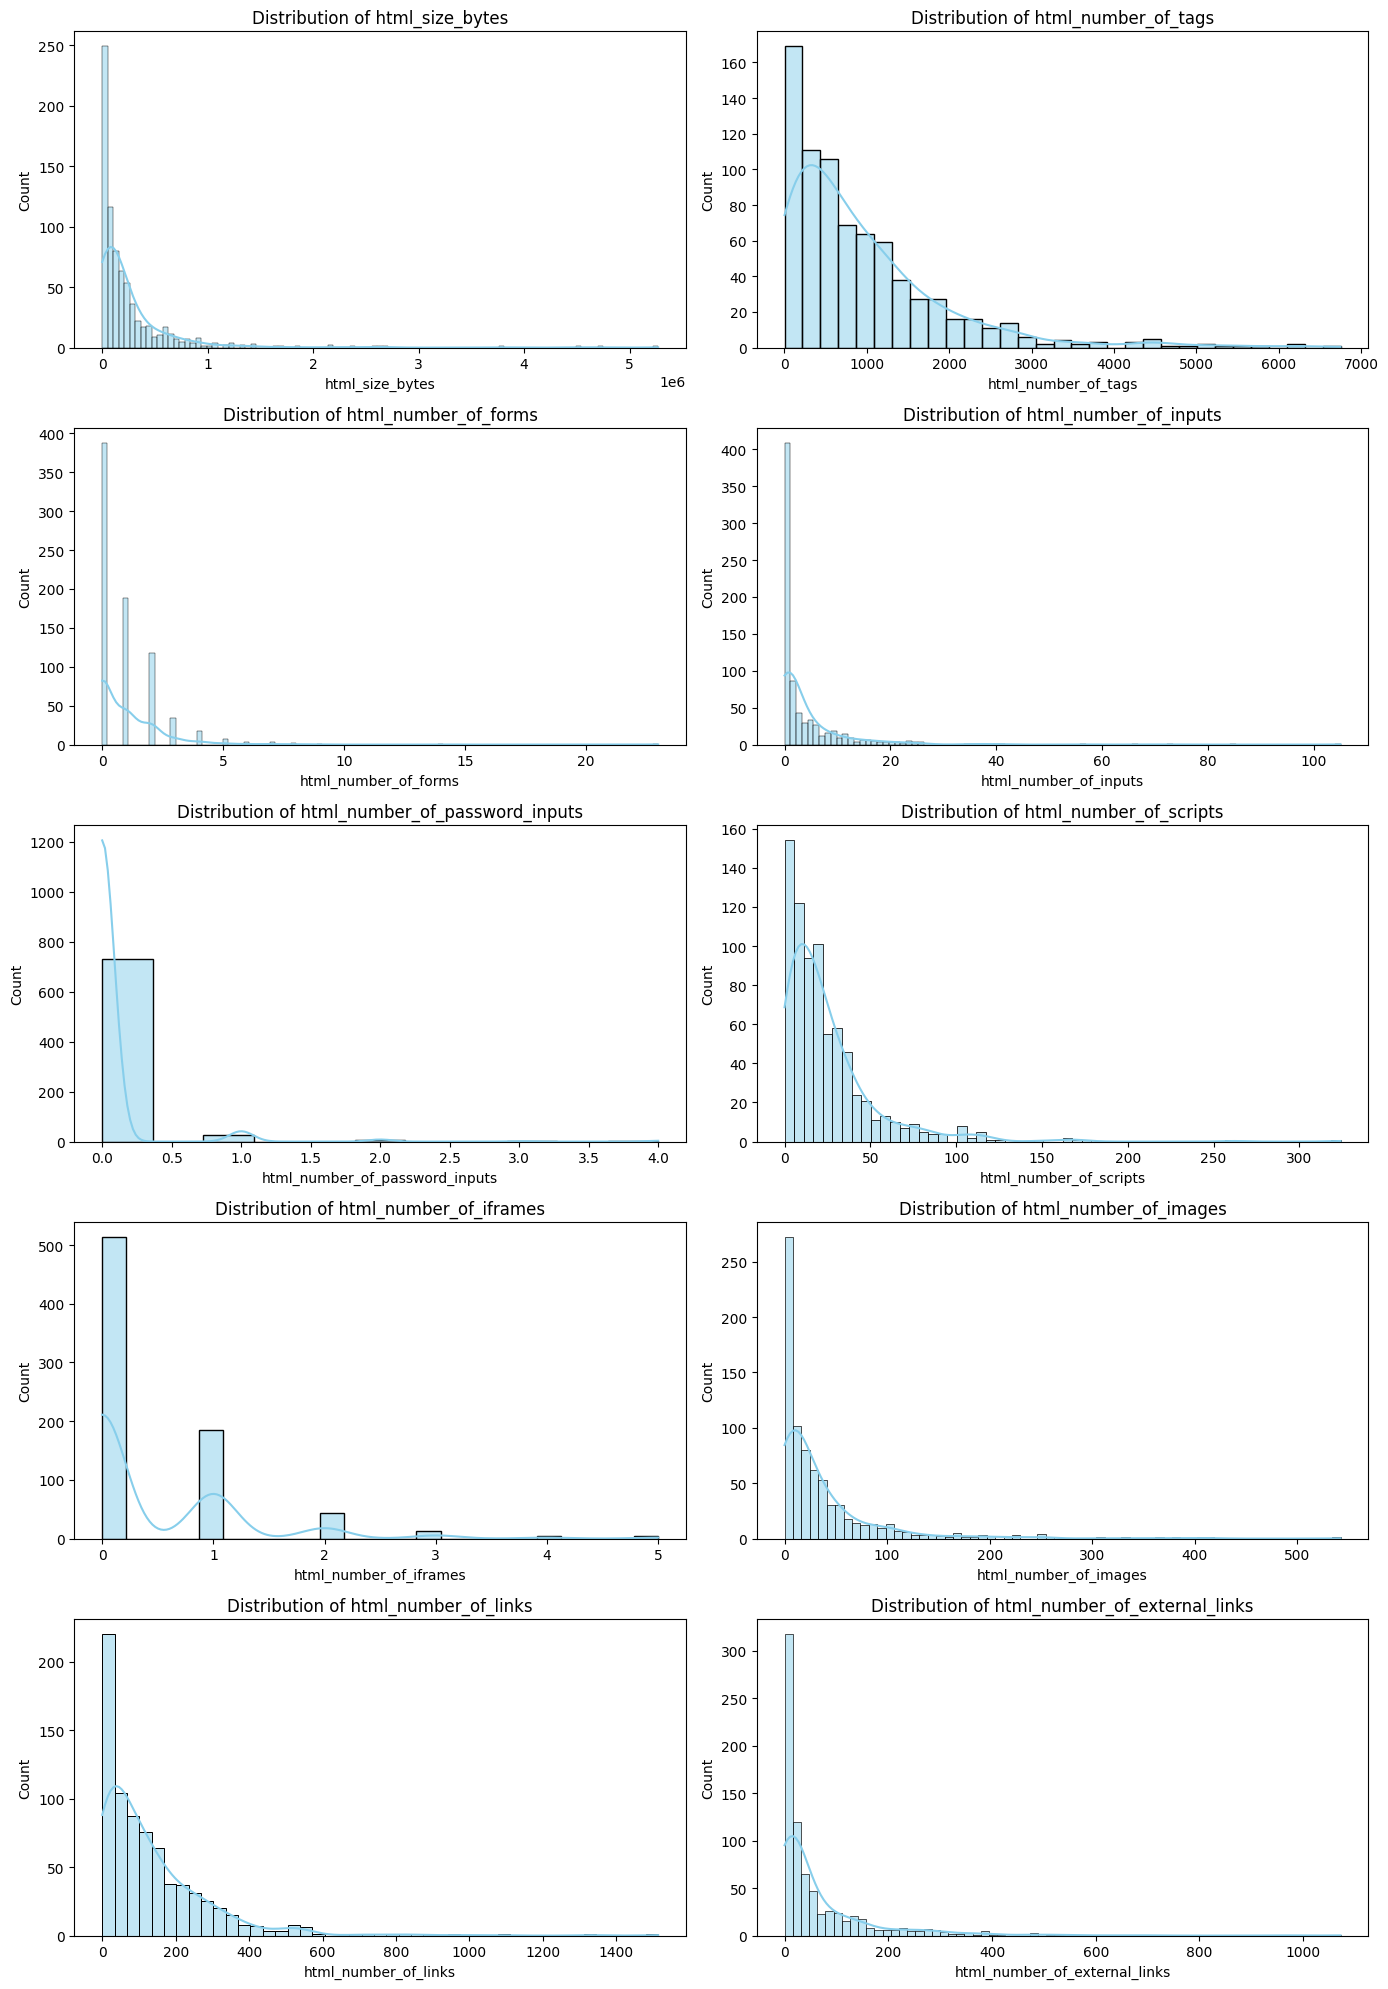

In [ ]:
# CELL 8 — HTML EDA
print("--- HTML Feature Summary ---")
display(df_html_features.describe().T)

# Create distribution plots
features_to_plot = [
    'html_size_bytes', 'html_number_of_tags', 'html_number_of_forms',
    'html_number_of_inputs', 'html_number_of_password_inputs',
    'html_number_of_scripts', 'html_number_of_iframes',
    'html_number_of_images', 'html_number_of_links', 'html_number_of_external_links'
]

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.ravel()

for i, col in enumerate(features_to_plot):
    if col in df_html_features.columns:
        sns.histplot(df_html_features[col], ax=axes[i], kde=True, color='skyblue')
        axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "eda" / "html" / "html_distributions.png")
plt.show()

In [ ]:
# CELL 9 — HTML Outlier Analysis
outlier_report = []

print("Calculating HTML Outliers using IQR...")
for col in df_html_features.select_dtypes(include=[np.number]).columns:
    q1 = df_html_features[col].quantile(0.25)
    q3 = df_html_features[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df_html_features[(df_html_features[col] < lower_bound) | (df_html_features[col] > upper_bound)]
    outlier_report.append({
        'feature': col,
        'outlier_count': len(outliers),
        'outlier_percentage': (len(outliers) / len(df_html_features)) * 100
    })

df_outliers = pd.DataFrame(outlier_report)
df_outliers.to_csv(OUTPUT_PATH / "outlier_report.csv", index=False)
display(df_outliers.head(10))

Calculating HTML Outliers using IQR...


,feature,outlier_count,outlier_percentage
0,id,0,0.000000
1,html_size_bytes,71,9.317585
2,html_character_count,73,9.580052
3,html_line_count,70,9.186352
4,html_number_of_tags,40,5.249344
5,html_number_of_unique_tags,58,7.611549
6,html_number_of_attributes,44,5.774278
7,html_number_of_comments,90,11.811024
8,html_dom_depth,12,1.574803
9,html_max_children,37,4.855643


In [ ]:
print(df_html_features.info())
df_html_features.eq(0).sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 60 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 762 non-null    int64  
 1   html_size_bytes                    762 non-null    int64  
 2   html_character_count               762 non-null    int64  
 3   html_line_count                    762 non-null    int64  
 4   html_number_of_tags                762 non-null    int64  
 5   html_number_of_unique_tags         762 non-null    int64  
 6   html_number_of_attributes          762 non-null    int64  
 7   html_number_of_comments            762 non-null    int64  
 8   html_dom_depth                     762 non-null    int64  
 9   html_max_children                  762 non-null    int64  
 10  html_average_children              762 non-null    float64
 11  html_number_of_forms               762 non-null    int64  

,0
id,0
html_size_bytes,0
html_character_count,0
html_line_count,0
html_number_of_tags,0
html_number_of_unique_tags,0
html_number_of_attributes,15
html_number_of_comments,145
html_dom_depth,0
html_max_children,0


In [ ]:
#Drop Col with Zero count more than 750
for col in df_html_features.columns :
    if df_html_features[col].eq(0).sum() > 750:
        df_html_features.drop(col, axis=1, inplace=True)
df_html_features


# Fill zero values with the mean of the column
# Mean includes the zero values

for col in df_html_features.columns:

    if  col != 'id':

        # Mean = sum of ALL values / total number of values
        mean_value = df_html_features[col].mean()

        # Replace 0 with the calculated mean
        df_html_features.loc[
            df_html_features[col] == 0, col
        ] = mean_value


# Display statistics

print(df_html_features.eq(0).sum())
print(df_html_features.isna().sum())
print(df_html_features.info())
df_html_features.describe().T




id                                   0
html_size_bytes                      0
html_character_count                 0
html_line_count                      0
html_number_of_tags                  0
html_number_of_unique_tags           0
html_number_of_attributes            0
html_number_of_comments              0
html_dom_depth                       0
html_max_children                    0
html_average_children                0
html_number_of_forms                 0
html_number_of_inputs                0
html_number_of_password_inputs       0
html_number_of_email_inputs          0
html_number_of_text_inputs           0
html_number_of_hidden_inputs         0
html_number_of_submit_inputs         0
html_number_of_buttons               0
html_number_of_scripts               0
html_number_of_inline_scripts        0
html_number_of_external_scripts      0
html_number_of_javascript_urls       0
html_number_of_iframes               0
html_number_of_external_iframes      0
html_number_of_images    

,count,mean,std,min,25%,50%,75%,max
id,762.0,381.500000,220.114743,1.000000,191.250000,381.500000,571.750000,7.620000e+02
html_size_bytes,762.0,252048.402887,460726.345629,65.000000,36175.250000,113832.000000,276174.250000,5.270161e+06
html_character_count,762.0,249363.437008,450942.721627,65.000000,35273.000000,111836.500000,267207.500000,5.250933e+06
html_line_count,762.0,2045.291339,3187.714569,1.000000,156.500000,826.000000,2481.750000,2.491100e+04
html_number_of_tags,762.0,947.266404,1004.076228,2.000000,261.000000,634.500000,1279.500000,6.750000e+03
html_number_of_unique_tags,762.0,30.188976,11.339278,2.000000,25.000000,31.000000,36.000000,8.000000e+01
html_number_of_attributes,762.0,1743.562393,2018.935981,2.000000,432.000000,1106.000000,2290.750000,1.664600e+04
html_number_of_comments,762.0,90.058931,437.840515,1.000000,6.000000,22.000000,75.661417,7.164000e+03
html_dom_depth,762.0,17.224409,8.151379,2.000000,12.000000,17.000000,22.000000,4.900000e+01
html_max_children,762.0,63.468504,66.904228,1.000000,27.000000,48.000000,79.000000,8.060000e+02


In [ ]:
#save HTML features
df_html_features.to_csv(OUTPUT_PATH / "html_features.csv", index=False)

In [ ]:
# CELL 10 — Validate TXT Files
text_validation = []

print("Validating TXT file existence...")
for _, row in tqdm(df_csv.iterrows(), total=len(df_csv)):
    file_id = str(row['id'])
    col_name = 'text_file' if 'text_file' in df_csv.columns else None
    filename = str(row[col_name]) if col_name and pd.notna(row[col_name]) else f"{file_id}.txt"
    file_path = TEXT_DIR / filename
    text_validation.append({
        'id': row['id'],
        'text_exists': int(file_path.is_file()),
        'text_path': str(file_path)
    })

df_text_val = pd.DataFrame(text_validation)
df_text_val.to_csv(OUTPUT_PATH / "text_validation_report.csv", index=False)
print(f"Validated {len(df_text_val)} text assets. Missing: {(df_text_val['text_exists'] == 0).sum()}")

Validating TXT file existence...


  0%|          | 0/762 [00:00<?, ?it/s]

Validated 762 text assets. Missing: 0


In [ ]:
# CELL 11 — Clean Text
import html

def clean_text(text):
    if not text or not isinstance(text, str):
        return ""
    # 1. Unicode normalization
    text = unicodedata.normalize('NFKC', text)
    # 2. HTML entity decoding
    text = html.unescape(text)
    # 3. Lowercasing
    text = text.lower()
    # 4. Remove control characters (except newline and tab)
    text = "".join(ch for ch in text if unicodedata.category(ch)[0] != "C" or ch in "\n\t")
    # 5. Whitespace normalization
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n+', '\n', text)
    return text.strip()

In [ ]:
# CELL 12 — Extract Text Statistical Features
def extract_text_features(text, file_id):
    features = {'id': file_id}

    # Pre-calculated features defaults
    features.update({
        'text_character_count': len(text),
        'text_word_count': len(text.split()),
        'text_unique_word_count': len(set(text.split())),
        'text_line_count': text.count('\n') + 1 if text else 0,
        'text_digit_count': sum(c.isdigit() for c in text),
        'text_uppercase_count': sum(c.isupper() for c in text),  # Note: text is lowercased for keyword counts, but let's count original string for properties
    })

    # Safe ratio calculation
    features['text_unique_word_ratio'] = features['text_unique_word_count'] / max(features['text_word_count'], 1)
    features['text_digit_ratio'] = features['text_digit_count'] / max(features['text_character_count'], 1)
    features['text_uppercase_ratio'] = features['text_uppercase_count'] / max(features['text_character_count'], 1)

    # Sentences
    sentences = re.split(r'[.!?]+', text)
    features['text_sentence_count'] = len([s for s in sentences if s.strip()])

    # Averages
    features['text_average_word_length'] = np.mean([len(w) for w in text.split()]) if text.split() else 0
    features['text_average_sentence_length'] = np.mean([len(s.split()) for s in sentences if s.strip()]) if features['text_sentence_count'] > 0 else 0

    # Special Characters
    special_chars = re.findall(r'[^a-zA-Z0-9\s]', text)
    features['text_special_character_count'] = len(special_chars)
    features['text_special_character_ratio'] = len(special_chars) / max(features['text_character_count'], 1)

    features['text_exclamation_count'] = text.count('!')
    features['text_question_count'] = text.count('?')
    features['text_currency_symbol_count'] = len(re.findall(r'[$\u00A2-\u00A5\u20A0-\u20CF\uFFE0-\uFFE6]', text))

    # Structured elements
    features['text_url_like_token_count'] = len(re.findall(r'https?://\S+|www\.\S+', text))
    features['text_email_like_token_count'] = len(re.findall(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', text))
    features['text_phone_like_token_count'] = len(re.findall(r'\+?\d{1,4}[-\s]?\(?\d{1,3}\)?[-\s]?\d{1,4}[-\s]?\d{1,4}[-\s]?\d{1,9}', text))

    # Keyword counters
    keywords = ['login', 'password', 'verify', 'account', 'security', 'payment', 'bank', 'wallet', 'bonus', 'casino', 'betting', 'download', 'free']
    for kw in keywords:
        features[f'text_{kw}_count'] = text.count(kw)

    return features

text_features_list = []
cleaned_texts = [] # Save for SVD/TFIDF

for _, row in tqdm(df_text_val.iterrows(), total=len(df_text_val)):
    raw_txt = ""
    if row['text_exists']:
        try:
            with open(row['text_path'], 'r', encoding='utf-8', errors='ignore') as f:
                raw_txt = f.read()
        except:
            pass

    cleaned = clean_text(raw_txt)
    cleaned_texts.append(cleaned)
    feat = extract_text_features(cleaned, row['id'])
    text_features_list.append(feat)

df_text_Statical_features = pd.DataFrame(text_features_list)

  0%|          | 0/762 [00:00<?, ?it/s]

In [ ]:
print(df_text_Statical_features.info())
print(df_text_Statical_features.eq(0).sum())
print(df_text_Statical_features.columns)

df_text_Statical_features.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            762 non-null    int64  
 1   text_character_count          762 non-null    int64  
 2   text_word_count               762 non-null    int64  
 3   text_unique_word_count        762 non-null    int64  
 4   text_line_count               762 non-null    int64  
 5   text_digit_count              762 non-null    int64  
 6   text_uppercase_count          762 non-null    int64  
 7   text_unique_word_ratio        762 non-null    float64
 8   text_digit_ratio              762 non-null    float64
 9   text_uppercase_ratio          762 non-null    float64
 10  text_sentence_count           762 non-null    int64  
 11  text_average_word_length      762 non-null    float64
 12  text_average_sentence_length  762 non-null    float64
 13  text_

,count,mean,std,min,25%,50%,75%,max
id,762.0,381.500000,220.114743,1.0,191.250000,381.500000,571.750000,762.000000
text_character_count,762.0,5345.730971,7121.386936,0.0,1091.250000,3106.000000,6677.000000,56236.000000
text_word_count,762.0,817.849081,1095.447645,0.0,172.500000,465.000000,1029.750000,8308.000000
text_unique_word_count,762.0,349.868766,359.399040,0.0,109.250000,251.500000,477.250000,2670.000000
text_line_count,762.0,0.985564,0.119357,0.0,1.000000,1.000000,1.000000,1.000000
text_digit_count,762.0,138.005249,378.422363,0.0,8.000000,41.000000,118.750000,7286.000000
text_uppercase_count,762.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
text_unique_word_ratio,762.0,0.573224,0.198028,0.0,0.453061,0.549411,0.679071,1.000000
text_digit_ratio,762.0,0.021916,0.033308,0.0,0.003282,0.012270,0.027779,0.445099
text_uppercase_ratio,762.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000


In [ ]:
#Drop Col with Zero count more than 750
for col in df_text_Statical_features.columns :
    if df_text_Statical_features[col].eq(0).sum() > 750:
        df_text_Statical_features.drop(col, axis=1, inplace=True)
df_text_Statical_features


# Fill zero values with the mean of the column
# Mean includes the zero values

for col in df_text_Statical_features.columns:

    if  col != 'id':

        # Mean = sum of ALL values / total number of values
        mean_value = df_text_Statical_features[col].mean()

        # Replace 0 with the calculated mean
        df_text_Statical_features.loc[
            df_text_Statical_features[col] == 0, col
        ] = mean_value


# Display statistics

print(df_text_Statical_features.eq(0).sum())
print(df_text_Statical_features.isna().sum())
print(df_text_Statical_features.info())
df_text_Statical_features.describe().T




id                              0
text_character_count            0
text_word_count                 0
text_unique_word_count          0
text_line_count                 0
text_digit_count                0
text_unique_word_ratio          0
text_digit_ratio                0
text_sentence_count             0
text_average_word_length        0
text_average_sentence_length    0
text_special_character_count    0
text_special_character_ratio    0
text_exclamation_count          0
text_question_count             0
text_currency_symbol_count      0
text_url_like_token_count       0
text_email_like_token_count     0
text_phone_like_token_count     0
text_login_count                0
text_password_count             0
text_verify_count               0
text_account_count              0
text_security_count             0
text_payment_count              0
text_bank_count                 0
text_wallet_count               0
text_bonus_count                0
text_casino_count               0
text_betting_c

,count,mean,std,min,25%,50%,75%,max
id,762.0,381.500000,220.114743,1.000000,191.250000,381.500000,571.750000,762.000000
text_character_count,762.0,5422.900316,7091.905268,3.000000,1214.750000,3219.500000,6677.000000,56236.000000
text_word_count,762.0,829.655302,1090.961767,1.000000,191.250000,485.500000,1029.750000,8308.000000
text_unique_word_count,762.0,354.919365,356.893204,1.000000,114.750000,258.500000,477.250000,2670.000000
text_line_count,762.0,0.999792,0.001723,0.985564,1.000000,1.000000,1.000000,1.000000
text_digit_count,762.0,160.100578,373.712940,1.000000,24.250000,80.000000,138.005249,7286.000000
text_unique_word_ratio,762.0,0.581498,0.185464,0.111372,0.461106,0.555250,0.679071,1.000000
text_digit_ratio,762.0,0.025425,0.031939,0.000385,0.008675,0.020202,0.027779,0.445099
text_sentence_count,762.0,48.625018,127.243139,1.000000,9.000000,23.500000,47.933071,2737.000000
text_average_word_length,762.0,5.734076,2.115619,3.000000,5.079572,5.434702,5.798372,41.593458


In [ ]:
# CELL 12b — Install & Import SBERT Dependencies (NEW)
# Run this ONCE if you haven't installed SBERT

# !pip install sentence-transformers transformers torch datasets accelerate

import torch
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation
from torch.utils.data import DataLoader
import gc
import os

# Set device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"  Using device: {DEVICE}")

if DEVICE == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

  Using device: cuda
   GPU: Tesla T4
   Memory: 15.64 GB


In [ ]:
# CELL 12c — Prepare SBERT Training Data (NEW)
# Creates positive/negative pairs from your labeled websites

# ---- 1. Load labels from original dataset ----
df_labels = df_csv.copy()

# Confirm label columns exist
print("Available columns in df_csv:", df_labels.columns.tolist())

# Standardize label column names
label_col_risk = None
label_col_cat = None

for col in df_labels.columns:
    if 'risk' in col.lower():
        label_col_risk = col
    if 'categor' in col.lower():
        label_col_cat = col

if label_col_risk is None or label_col_cat is None:
    raise ValueError(" Could not find risk/category columns in df_csv. Please verify.")

print(f" Using risk column: '{label_col_risk}'")
print(f" Using category column: '{label_col_cat}'")

# ---- 2. Merge labels with cleaned texts ----
df_sbert = df_text_Statical_features[['id']].copy()
df_sbert['text'] = cleaned_texts
df_sbert = df_sbert.merge(
    df_labels[['id', label_col_risk, label_col_cat]].rename(
        columns={label_col_risk: 'risk', label_col_cat: 'category'}
    ),
    on='id',
    how='left'
)

print(f"\n Merged dataset shape: {df_sbert.shape}")
print(f"   Labeled rows: {df_sbert['risk'].notna().sum()}")
print(f"   Unlabeled rows: {df_sbert['risk'].isna().sum()}")

# ---- 3. Check label distribution ----
print("\n Risk distribution:")
print(df_sbert['risk'].value_counts(dropna=False))

print("\n Category distribution:")
print(df_sbert['category'].value_counts(dropna=False).head(20))

# ---- 4. Filter only labeled data for training ----
df_labeled = df_sbert[df_sbert['risk'].notna() & df_sbert['category'].notna()].copy()
df_labeled = df_labeled[df_labeled['text'].str.len() > 50]  # Skip too-short texts

print(f"\n Labeled + valid text rows: {len(df_labeled)}")

# ---- 5. Create training pairs (contrastive learning) ----
def create_training_pairs(df, max_pairs_per_class=20, max_negatives_per_pair=3):
    """Create positive and negative pairs for contrastive learning"""
    train_examples = []

    # Group by (risk, category) - websites with SAME label are POSITIVE pairs
    label_groups = {}
    for _, row in df.iterrows():
        key = (row['risk'], row['category'])
        if key not in label_groups:
            label_groups[key] = []
        label_groups[key].append(row['text'])

    print(f"Found {len(label_groups)} unique label groups")
    for key, texts in label_groups.items():
        print(f"   {key}: {len(texts)} samples")

    # ---- Positive pairs (same label) ----
    for key, texts in label_groups.items():
        if len(texts) < 2:
            continue
        # Limit pairs per group to avoid class imbalance
        count = 0
        for i in range(len(texts)):
            for j in range(i + 1, len(texts)):
                train_examples.append(InputExample(
                    texts=[texts[i], texts[j]],
                    label=1.0
                ))
                count += 1
                if count >= max_pairs_per_class:
                    break
            if count >= max_pairs_per_class:
                break

    # ---- Negative pairs (different label) ----
    label_keys = [k for k, v in label_groups.items() if len(v) >= 1]
    for i, key1 in enumerate(label_keys):
        for key2 in label_keys[i + 1:]:
            texts1 = label_groups[key1]
            texts2 = label_groups[key2]

            # Take a few pairs from different labels
            for k in range(min(max_negatives_per_pair, len(texts1), len(texts2))):
                train_examples.append(InputExample(
                    texts=[texts1[k], texts2[k]],
                    label=0.0
                ))

    return train_examples

train_examples = create_training_pairs(df_labeled, max_pairs_per_class=20)

print(f"\n Total training pairs: {len(train_examples)}")
positive = sum(1 for ex in train_examples if ex.label == 1.0)
negative = len(train_examples) - positive
print(f"   Positive (same label): {positive}")
print(f"   Negative (different label): {negative}")

Available columns in df_csv: ['id', 'url', 'final_url', 'http_status', 'html_file', 'text_file', 'thirdparty_file', 'risk', 'category', 'illicit_activity_type', 'text_length', 'collected_at']
 Using risk column: 'risk'
 Using category column: 'category'

 Merged dataset shape: (762, 4)
   Labeled rows: 762
   Unlabeled rows: 0

 Risk distribution:
risk
Safe        351
Moderate    222
High        189
Name: count, dtype: int64

 Category distribution:
category
Tech              219
Scam              110
Phishing           61
Social             51
E-commerce         45
Finance            42
News               39
Education          39
Government         35
Betting            29
Business           25
Entertainment      17
Adult              16
Malware            15
Domain Parking      7
Dating              3
Health              3
Other               2
Food                2
Travel              1
Name: count, dtype: int64

 Labeled + valid text rows: 721
Found 33 unique label groups
   ('High

In [ ]:
# CELL 13 — Fine-Tune SBERT (REPLACES TF-IDF + SVD)
# Fine-tunes Sentence-BERT on cybersecurity domain data

# ---- 1. Load base SBERT model ----
# Options:
#   'all-MiniLM-L6-v2'      → 384 dims, fast (RECOMMENDED for first run)
#   'all-mpnet-base-v2'     → 768 dims, best quality, slower
#   'allenai/scibert_scivocab_uncased' → 768 dims, scientific

BASE_MODEL = 'all-MiniLM-L6-v2'
print(f" Loading base model: {BASE_MODEL}")
base_model = SentenceTransformer(BASE_MODEL, device=DEVICE)
EMBEDDING_DIM = base_model.get_sentence_embedding_dimension()
print(f" Loaded. Embedding dim: {EMBEDDING_DIM}")

# ---- 2. Prepare DataLoader ----
BATCH_SIZE = 16
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=BATCH_SIZE)

# ---- 3. Define contrastive loss ----
train_loss = losses.ContrastiveLoss(model=base_model)

# ---- 4. Fine-tune ----
FINETUNED_DIR = OUTPUT_PATH / "finetuned_sbert"
FINETUNED_DIR.mkdir(parents=True, exist_ok=True)

EPOCHS = 10
WARMUP_STEPS = max(100, int(len(train_examples) * EPOCHS * 0.1))

print(f"\n Starting fine-tuning...")
print(f"   Epochs: {EPOCHS}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Warmup steps: {WARMUP_STEPS}")
print(f"   Training pairs: {len(train_examples)}")

try:
    base_model.fit(
        train_objectives=[(train_dataloader, train_loss)],
        epochs=EPOCHS,
        warmup_steps=WARMUP_STEPS,
        output_path=str(FINETUNED_DIR),
        show_progress_bar=True,
        use_amp=(DEVICE == 'cuda'),
        save_best_model=True,
        checkpoint_path=str(FINETUNED_DIR / "checkpoints"),
        checkpoint_save_steps=len(train_dataloader)
    )
    print(f"\n Fine-tuned model saved to: {FINETUNED_DIR}")
except Exception as e:
    print(f" Fine-tuning error: {e}")
    print("   Continuing with base model.")

# Cleanup memory
gc.collect()
if DEVICE == 'cuda':
    torch.cuda.empty_cache()

 Loading base model: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Fine-tuned model saved to: /content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features/finetuned_sbert


In [ ]:
# CELL 13b — Generate SBERT Embeddings (NEW)
# Uses the fine-tuned model to generate semantic embeddings

# ---- 1. Load fine-tuned model ----
FINETUNED_DIR = OUTPUT_PATH / "finetuned_sbert"

if FINETUNED_DIR.exists() and (FINETUNED_DIR / "config.json").exists():
    print(f" Loading fine-tuned model from: {FINETUNED_DIR}")
    sbert_model = SentenceTransformer(str(FINETUNED_DIR), device=DEVICE)
    model_tag = 'finetuned'
else:
    print(f" Fine-tuned model not found. Using base model.")
    sbert_model = SentenceTransformer(BASE_MODEL, device=DEVICE)
    model_tag = 'base'

EMBEDDING_DIM = sbert_model.get_sentence_embedding_dimension()
print(f" Model ready. Embedding dim: {EMBEDDING_DIM}")

# ---- 2. Truncate long texts to avoid token limit ----
MAX_CHARS = 2000  # SBERT works best with ~500 tokens (~2000 chars)
texts_truncated = [t[:MAX_CHARS] if t else "" for t in cleaned_texts]

# ---- 3. Generate embeddings in batches ----
print(f"\nGenerating SBERT embeddings for {len(texts_truncated)} texts...")
embeddings = sbert_model.encode(
    texts_truncated,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True  # L2 norm for cosine similarity
)

print(f"Generated embeddings shape: {embeddings.shape}")

# ---- 4. Store as DataFrame ----
sbert_cols = [f'text_sbert_{i:03d}' for i in range(EMBEDDING_DIM)]
df_sbert_features = pd.DataFrame(embeddings, columns=sbert_cols)
df_sbert_features.insert(0, 'id', df_text_Statical_features['id'].values)

print(f"\nSBERT feature matrix shape: {df_sbert_features.shape}")
print(f"   Columns: id + {EMBEDDING_DIM} SBERT dimensions")

# ---- 5. Sanity check: cosine similarity between similar sites ----
from sklearn.metrics.pairwise import cosine_similarity

# Sample 5 pairs to verify semantic quality
sample_indices = np.random.choice(len(embeddings), size=5, replace=False)
sample_similarities = cosine_similarity(embeddings[sample_indices])

print("\nSample cosine similarities (should be near 1.0 on diagonal):")
print(np.round(sample_similarities, 3))

 Loading fine-tuned model from: /content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features/finetuned_sbert


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

 Model ready. Embedding dim: 384

Generating SBERT embeddings for 762 texts...


Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Generated embeddings shape: (762, 384)

SBERT feature matrix shape: (762, 385)
   Columns: id + 384 SBERT dimensions

Sample cosine similarities (should be near 1.0 on diagonal):
[[1.    0.565 0.386 0.574 0.772]
 [0.565 1.    0.542 0.711 0.732]
 [0.386 0.542 1.    0.535 0.559]
 [0.574 0.711 0.535 1.    0.778]
 [0.772 0.732 0.559 0.778 1.   ]]


In [ ]:
# CELL 13c — Merge SBERT into Text Features (NEW)
# Combines statistical features + SBERT embeddings

print("Merging SBERT embeddings with statistical text features...")

# Merge on 'id'
df_text_features_v2 = df_text_Statical_features.merge(
    df_sbert_features,
    on='id',
    how='left'
)

# Fill any NaN SBERT values with 0 (websites without text)
sbert_cols = [c for c in df_text_features_v2.columns if c.startswith('text_sbert_')]
df_text_features_v2[sbert_cols] = df_text_features_v2[sbert_cols].fillna(0)

print(f"Combined text features shape: {df_text_features_v2.shape}")
print(f"   Statistical features: {len([c for c in df_text_features_v2.columns if c.startswith('text_') and not c.startswith('text_sbert_')])}")
print(f"   SBERT features: {len(sbert_cols)}")

# Save intermediate version
df_text_features_v2.to_csv(OUTPUT_PATH / "text_features_sbert.csv", index=False)
print(f"Saved to: {OUTPUT_PATH / 'text_features_sbert.csv'}")

Merging SBERT embeddings with statistical text features...
Combined text features shape: (762, 416)
   Statistical features: 31
   SBERT features: 384
Saved to: /content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features/text_features_sbert.csv


In [ ]:
df_text_features=pd.read_csv(OUTPUT_PATH / "text_features_sbert.csv")
df_text_features.head()

,id,text_character_count,text_word_count,text_unique_word_count,text_line_count,text_digit_count,text_unique_word_ratio,text_digit_ratio,text_sentence_count,text_average_word_length,...,text_sbert_374,text_sbert_375,text_sbert_376,text_sbert_377,text_sbert_378,text_sbert_379,text_sbert_380,text_sbert_381,text_sbert_382,text_sbert_383
0,1,2389.0,397.0,249.0,1.0,50.000000,0.627204,0.020929,38.0,5.020151,...,-0.021576,0.007998,-0.026411,0.011555,0.033669,0.090041,0.033973,-0.036150,-0.040591,0.052718
1,2,1595.0,250.0,198.0,1.0,6.000000,0.792000,0.003762,63.0,5.384000,...,0.028538,0.019161,-0.011921,0.047990,0.030131,0.057110,-0.040516,-0.019223,-0.048003,-0.026267
2,3,1762.0,309.0,184.0,1.0,4.000000,0.595469,0.002270,34.0,4.705502,...,0.000923,0.008458,0.040318,0.055159,-0.051932,0.031561,0.061522,-0.031878,-0.000609,0.032233
3,4,202.0,39.0,30.0,1.0,138.005249,0.769231,0.021916,5.0,4.205128,...,0.007748,-0.004701,-0.015516,0.004632,0.042061,0.081243,0.031919,-0.007719,-0.040469,0.046447
4,5,182.0,17.0,16.0,1.0,17.000000,0.941176,0.093407,8.0,9.764706,...,0.044735,-0.004622,0.070892,0.067603,-0.005248,0.072684,0.061519,0.070393,-0.020807,0.011403


TEXT FEATURE EDA

--- Statistical Features ---


,count,mean,std,min,25%,50%,75%,max
id,762.0,381.500000,220.114743,1.000000,191.250000,381.500000,571.750000,762.000000
text_character_count,762.0,5422.900316,7091.905268,3.000000,1214.750000,3219.500000,6677.000000,56236.000000
text_word_count,762.0,829.655302,1090.961767,1.000000,191.250000,485.500000,1029.750000,8308.000000
text_unique_word_count,762.0,354.919365,356.893204,1.000000,114.750000,258.500000,477.250000,2670.000000
text_line_count,762.0,0.999792,0.001723,0.985564,1.000000,1.000000,1.000000,1.000000
text_digit_count,762.0,160.100578,373.712940,1.000000,24.250000,80.000000,138.005249,7286.000000
text_unique_word_ratio,762.0,0.581498,0.185464,0.111372,0.461106,0.555250,0.679071,1.000000
text_digit_ratio,762.0,0.025425,0.031939,0.000385,0.008675,0.020202,0.027779,0.445099
text_sentence_count,762.0,48.625018,127.243139,1.000000,9.000000,23.500000,47.933071,2737.000000
text_average_word_length,762.0,5.734076,2.115619,3.000000,5.079572,5.434702,5.798372,41.593458



--- SBERT Embeddings ---
Number of SBERT dimensions: 384
Embedding norm stats (should be ~1.0 due to normalization):
  Mean: 1.0000, Std: 0.0000, Min: 1.0000, Max: 1.0000

🔍 Running t-SNE for SBERT embedding visualization...


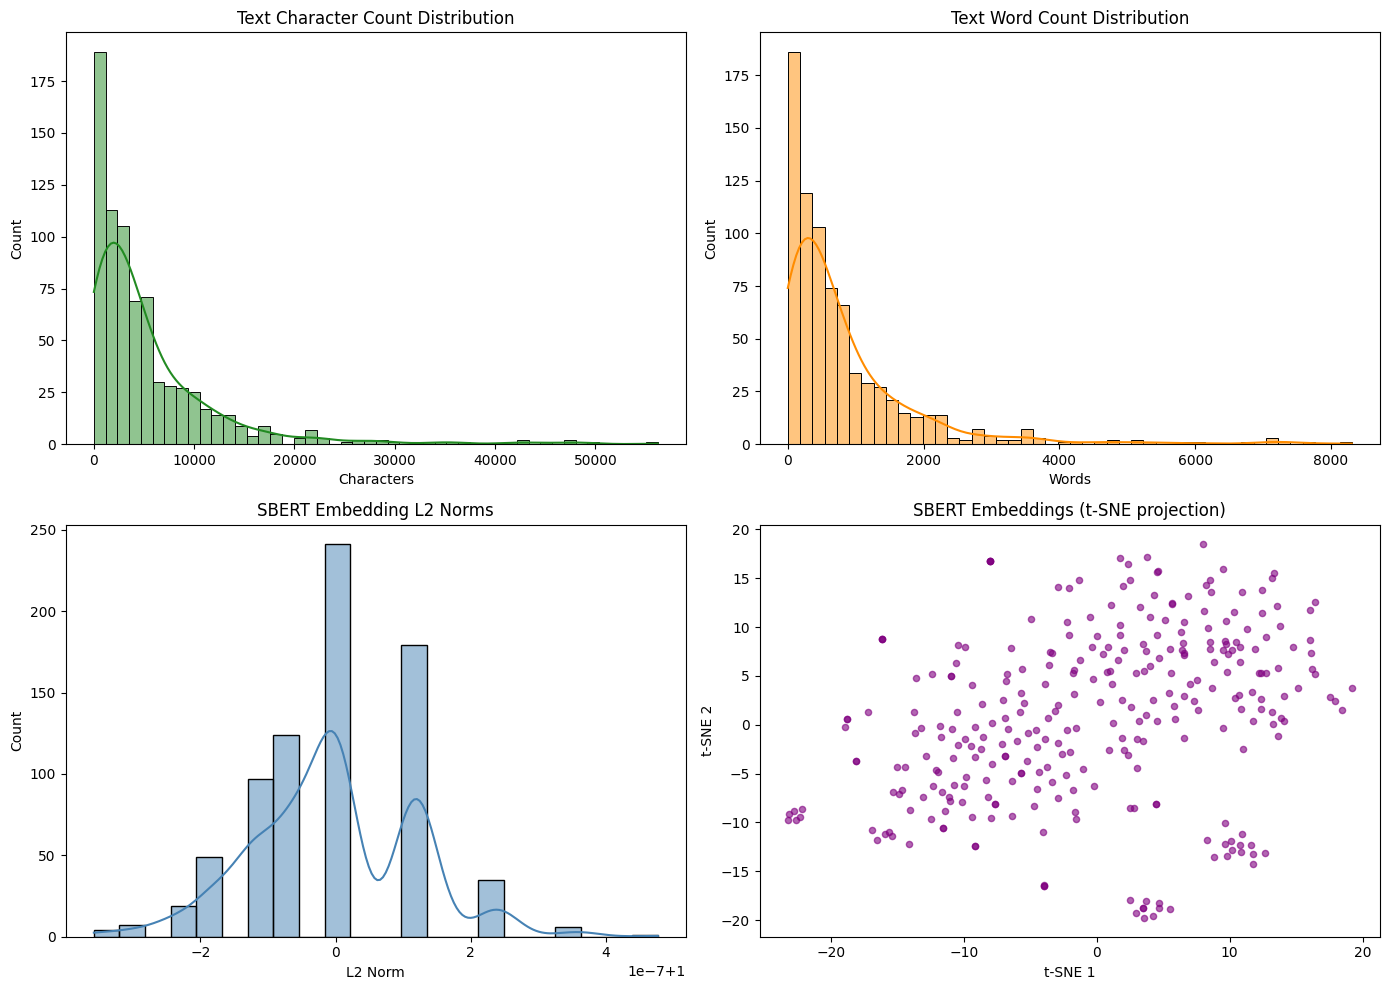


--- Semantic Quality Check ---

Cosine similarity between risk-level centroids:
   (Lower = better separation, Higher = more overlap)
   High ↔ High: 1.0000
   High ↔ Moderate: 0.9606
   High ↔ Safe: 0.9884
   Moderate ↔ Moderate: 1.0000
   Moderate ↔ Safe: 0.9556
   Safe ↔ Safe: 1.0000

 Text EDA complete


In [ ]:
# CELL 14 — Text EDA with SBERT (UPDATED)

print("=" * 60)
print("TEXT FEATURE EDA")
print("=" * 60)

# ---- 1. Statistical feature EDA ----
print("\n--- Statistical Features ---")
stat_cols = [c for c in df_text_features_v2.columns
             if c.startswith('text_') and not c.startswith('text_sbert_')]
df_stat_view = df_text_features_v2[['id'] + stat_cols]
display(df_stat_view.describe().T.head(30))

# ---- 2. SBERT embedding EDA ----
print("\n--- SBERT Embeddings ---")
sbert_cols = [c for c in df_text_features_v2.columns if c.startswith('text_sbert_')]
print(f"Number of SBERT dimensions: {len(sbert_cols)}")
print(f"Embedding norm stats (should be ~1.0 due to normalization):")
norms = np.linalg.norm(df_text_features_v2[sbert_cols].values, axis=1)
print(f"  Mean: {norms.mean():.4f}, Std: {norms.std():.4f}, Min: {norms.min():.4f}, Max: {norms.max():.4f}")

# ---- 3. Visualizations ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Text character count distribution
sns.histplot(df_text_features_v2['text_character_count'], ax=axes[0, 0], color='forestgreen', kde=True)
axes[0, 0].set_title('Text Character Count Distribution')
axes[0, 0].set_xlabel('Characters')

# Plot 2: Text word count distribution
sns.histplot(df_text_features_v2['text_word_count'], ax=axes[0, 1], color='darkorange', kde=True)
axes[0, 1].set_title('Text Word Count Distribution')
axes[0, 1].set_xlabel('Words')

# Plot 3: SBERT embedding norm distribution
sns.histplot(norms, ax=axes[1, 0], color='steelblue', kde=True)
axes[1, 0].set_title('SBERT Embedding L2 Norms')
axes[1, 0].set_xlabel('L2 Norm')

# Plot 4: SBERT dimensionality reduction (UMAP or t-SNE)
try:
    from sklearn.manifold import TSNE
    print("\n🔍 Running t-SNE for SBERT embedding visualization...")

    # Use a sample for speed
    sample_size = min(300, len(df_text_features_v2))
    sample_idx = np.random.choice(len(df_text_features_v2), sample_size, replace=False)

    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, sample_size-1))
    emb_2d = tsne.fit_transform(df_text_features_v2.iloc[sample_idx][sbert_cols].values)

    axes[1, 1].scatter(emb_2d[:, 0], emb_2d[:, 1], alpha=0.6, s=20, c='purple')
    axes[1, 1].set_title('SBERT Embeddings (t-SNE projection)')
    axes[1, 1].set_xlabel('t-SNE 1')
    axes[1, 1].set_ylabel('t-SNE 2')
except Exception as e:
    print(f" t-SNE failed: {e}")
    axes[1, 1].text(0.5, 0.5, f't-SNE unavailable:\n{e}', ha='center', va='center')
    axes[1, 1].set_title('SBERT Embeddings (t-SNE unavailable)')

plt.tight_layout()
(OUTPUT_PATH / "eda" / "text").mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_PATH / "eda" / "text" / "text_distributions_sbert.png", dpi=150)
plt.show()

# ---- 4. Semantic clustering check ----
print("\n--- Semantic Quality Check ---")
if 'risk' in df_sbert.columns:
    df_check = df_text_features_v2.merge(
        df_sbert[['id', 'risk']].dropna(),
        on='id', how='inner'
    )

    if len(df_check) > 10:
        # Group means per risk level
        risk_groups = df_check.groupby('risk')[sbert_cols].mean()

        # Compute similarity between group centroids
        risk_labels = risk_groups.index.tolist()
        centroids = risk_groups.values

        print("\nCosine similarity between risk-level centroids:")
        print("   (Lower = better separation, Higher = more overlap)")

        sim_matrix = cosine_similarity(centroids)
        for i, r1 in enumerate(risk_labels):
            for j, r2 in enumerate(risk_labels):
                if i <= j:
                    print(f"   {r1} ↔ {r2}: {sim_matrix[i, j]:.4f}")

print("\n Text EDA complete")

In [ ]:
# CELL 15 — Save Final Text Features (UPDATED)

# Save to disk
df_text_features_v2.to_csv(OUTPUT_PATH / "text_features_final.csv", index=False)
print(f"Saved final text features to: {OUTPUT_PATH / 'text_features_final.csv'}")
print(f"   Shape: {df_text_features_v2.shape}")

# Also save SBERT-only version
df_sbert_features.to_csv(OUTPUT_PATH / "text_sbert_embeddings.csv", index=False)
print(f"Saved SBERT-only embeddings to: {OUTPUT_PATH / 'text_sbert_embeddings.csv'}")
print(f"   Shape: {df_sbert_features.shape}")

Saved final text features to: /content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features/text_features_final.csv
   Shape: (762, 416)
Saved SBERT-only embeddings to: /content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features/text_sbert_embeddings.csv
   Shape: (762, 385)


In [ ]:
# ================================================================
# CELL 15 — Validate Third-Party JSON Files
# ================================================================

import json
import re
import numpy as np
import pandas as pd
from pathlib import Path
from urllib.parse import urlparse
from tqdm.auto import tqdm

tp_validation = []

print("Validating third-party JSON files...")

for _, row in tqdm(df_csv.iterrows(), total=len(df_csv)):

    file_id = str(row["id"])

    # Use thirdparty_file column if available
    if "thirdparty_file" in df_csv.columns and pd.notna(row["thirdparty_file"]):
        filename = str(row["thirdparty_file"])
    else:
        filename = f"{file_id}.json"

    file_path = THIRDPARTY_DIR / filename

    record = {
        "id": row["id"],
        "thirdparty_filename": filename,
        "thirdparty_path": str(file_path),
        "thirdparty_exists": 0,
        "thirdparty_readable": 0,
        "thirdparty_valid_json": 0,
        "thirdparty_nonempty": 0,
        "thirdparty_is_dict": 0,
        "thirdparty_error": ""
    }

    # ------------------------------------------------------------
    # 1. Check existence
    # ------------------------------------------------------------
    if not file_path.is_file():
        record["thirdparty_error"] = "File not found"
        tp_validation.append(record)
        continue

    record["thirdparty_exists"] = 1

    # ------------------------------------------------------------
    # 2. Read JSON
    # ------------------------------------------------------------
    try:
        with open(file_path, "r", encoding="utf-8") as f:
            raw_content = f.read()

        record["thirdparty_readable"] = 1

        if not raw_content.strip():
            record["thirdparty_error"] = "Empty JSON file"
            tp_validation.append(record)
            continue

        record["thirdparty_nonempty"] = 1

        # --------------------------------------------------------
        # 3. Parse JSON
        # --------------------------------------------------------
        try:
            data = json.loads(raw_content)
            record["thirdparty_valid_json"] = 1
        except json.JSONDecodeError as e:
            record["thirdparty_error"] = f"JSON decode error: {str(e)}"
            tp_validation.append(record)
            continue

        # --------------------------------------------------------
        # 4. Verify expected dictionary structure
        # --------------------------------------------------------
        if not isinstance(data, dict):
            record["thirdparty_error"] = "JSON root is not a dictionary"
            tp_validation.append(record)
            continue

        record["thirdparty_is_dict"] = 1

    except UnicodeDecodeError:
        record["thirdparty_error"] = "UTF-8 decoding error"

    except Exception as e:
        record["thirdparty_error"] = f"Unexpected error: {str(e)}"

    tp_validation.append(record)


# ------------------------------------------------------------
# Create validation dataframe
# ------------------------------------------------------------
df_tp_val = pd.DataFrame(tp_validation)

# Save report
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

df_tp_val.to_csv(
    OUTPUT_PATH / "thirdparty_validation_report.csv",
    index=False
)

print("\n================ THIRD-PARTY VALIDATION ================")

print(
    "Total records:",
    len(df_tp_val)
)

print(
    "Files found:",
    df_tp_val["thirdparty_exists"].sum()
)

print(
    "Readable:",
    df_tp_val["thirdparty_readable"].sum()
)

print(
    "Valid JSON:",
    df_tp_val["thirdparty_valid_json"].sum()
)

print(
    "Valid dictionary JSON:",
    df_tp_val["thirdparty_is_dict"].sum()
)

print(
    "Missing files:",
    (df_tp_val["thirdparty_exists"] == 0).sum()
)

print(
    "Invalid JSON:",
    (
        (df_tp_val["thirdparty_exists"] == 1) &
        (df_tp_val["thirdparty_valid_json"] == 0)
    ).sum()
)

print("========================================================")

Validating third-party JSON files...


  0%|          | 0/762 [00:00<?, ?it/s]


================ THIRD-PARTY VALIDATION ================
Total records: 762
Files found: 762
Readable: 762
Valid JSON: 762
Valid dictionary JSON: 762
Missing files: 0
Invalid JSON: 0


In [ ]:
# ================================================================
# CELL 16 — Parse and Clean Third-Party JSON
#              Based on Actual JSON Structure
# ================================================================

def load_clean_json(file_path):

    """
    Load and safely parse a third-party JSON file.

    Returns:
        dict  -> valid JSON dictionary
        {}    -> missing/invalid JSON
    """

    file_path = Path(file_path)

    if not file_path.is_file():
        return {}

    try:
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        if isinstance(data, dict):
            return data

        return {}

    except (json.JSONDecodeError, UnicodeDecodeError, OSError):
        return {}

    except Exception:
        return {}


# ------------------------------------------------------------
# Helper: Always return a list
# ------------------------------------------------------------

def safe_list(data, key):

    value = data.get(key, [])

    if value is None:
        return []

    if isinstance(value, list):
        return value

    # Handle accidental single values
    return [value]


# ------------------------------------------------------------
# Helper: Count string URLs
# ------------------------------------------------------------

def string_urls(items):

    return [
        item.strip()
        for item in items
        if isinstance(item, str) and item.strip()
    ]


# ------------------------------------------------------------
# Helper: Normalize URL
# ------------------------------------------------------------

def normalize_url(url):

    if not isinstance(url, str):
        return None

    url = url.strip()

    if not url:
        return None

    # Protocol-relative URL
    if url.startswith("//"):
        url = "https:" + url

    # Only treat HTTP/HTTPS as URLs
    if not url.startswith(("http://", "https://")):
        return None

    return url


# ------------------------------------------------------------
# Helper: Extract domain
# ------------------------------------------------------------

def extract_domain(url):

    url = normalize_url(url)

    if url is None:
        return None

    try:
        parsed = urlparse(url)

        domain = parsed.netloc.lower().strip()

        # Remove port
        domain = domain.split(":")[0]

        if domain:
            return domain

    except Exception:
        pass

    return None


# ------------------------------------------------------------
# Helper: IP address detection
# ------------------------------------------------------------

def is_ip_address(domain):

    if not isinstance(domain, str):
        return False

    pattern = (
        r"^(?:\d{1,3}\.){3}\d{1,3}$"
    )

    return bool(re.match(pattern, domain))


# ------------------------------------------------------------
# Helper: Count dictionaries by a field
# ------------------------------------------------------------

def count_form_input_types(form_inputs):

    counts = {
        "text": 0,
        "password": 0,
        "email": 0,
        "hidden": 0,
        "submit": 0,
        "button": 0,
        "number": 0,
        "tel": 0,
        "search": 0,
        "checkbox": 0,
        "radio": 0,
        "file": 0
    }

    for item in form_inputs:

        if isinstance(item, dict):

            input_type = str(
                item.get("type", "")
            ).strip().lower()

            if input_type in counts:
                counts[input_type] += 1

    return counts


print("Third-party JSON parser and cleaning functions loaded successfully.")

Third-party JSON parser and cleaning functions loaded successfully.


In [ ]:
# ================================================================
# CELL 17 — Extract Third-Party Features
#              Based on Actual JSON Schema
# ================================================================

def extract_third_party_features(data, file_id):

    features = {
        "id": file_id
    }

    # ============================================================
    # 1. LOAD ACTUAL JSON FIELDS
    # ============================================================

    external_scripts = safe_list(data, "external_scripts")
    external_iframes = safe_list(data, "external_iframes")
    external_images = safe_list(data, "external_images")
    external_stylesheets = safe_list(data, "external_stylesheets")
    external_fonts = safe_list(data, "external_fonts")
    external_fonts_css = safe_list(data, "external_fonts_css")

    form_actions = safe_list(data, "form_actions")
    form_inputs = safe_list(data, "form_inputs")

    analytics_endpoints = safe_list(
        data,
        "analytics_endpoints"
    )

    tracking_pixels = safe_list(
        data,
        "tracking_pixels"
    )

    external_links = safe_list(
        data,
        "external_links"
    )

    cdn_domains = safe_list(
        data,
        "cdn_domains"
    )

    social_media_widgets = safe_list(
        data,
        "social_media_widgets"
    )

    advertising_elements = safe_list(
        data,
        "advertising_elements"
    )

    javascript_frameworks = safe_list(
        data,
        "javascript_frameworks"
    )

    security_risks = safe_list(
        data,
        "security_risks"
    )

    third_party_domains = safe_list(
        data,
        "third_party_domains"
    )

    # ============================================================
    # 2. BASIC RESOURCE COUNTS
    # ============================================================

    features["tp_external_scripts"] = len(external_scripts)

    features["tp_external_iframes"] = len(external_iframes)

    features["tp_external_images"] = len(external_images)

    features["tp_external_stylesheets"] = len(external_stylesheets)

    features["tp_external_fonts"] = len(external_fonts)

    features["tp_external_fonts_css"] = len(external_fonts_css)

    features["tp_external_links"] = len(external_links)

    # ============================================================
    # 3. FORMS
    # ============================================================

    features["tp_form_actions"] = len(form_actions)

    features["tp_form_inputs"] = len(form_inputs)

    form_input_counts = count_form_input_types(
        form_inputs
    )

    features["tp_text_inputs"] = form_input_counts["text"]

    features["tp_password_inputs"] = form_input_counts["password"]

    features["tp_email_inputs"] = form_input_counts["email"]

    features["tp_hidden_inputs"] = form_input_counts["hidden"]

    features["tp_submit_inputs"] = form_input_counts["submit"]

    features["tp_button_inputs"] = form_input_counts["button"]

    features["tp_number_inputs"] = form_input_counts["number"]

    features["tp_tel_inputs"] = form_input_counts["tel"]

    features["tp_search_inputs"] = form_input_counts["search"]

    features["tp_checkbox_inputs"] = form_input_counts["checkbox"]

    features["tp_radio_inputs"] = form_input_counts["radio"]

    features["tp_file_inputs"] = form_input_counts["file"]

    # ============================================================
    # 4. FORM SECURITY STRUCTURAL FEATURES
    # ============================================================

    features["tp_has_password_input"] = int(
        features["tp_password_inputs"] > 0
    )

    features["tp_has_email_input"] = int(
        features["tp_email_inputs"] > 0
    )

    features["tp_has_login_related_form"] = int(
        (
            features["tp_password_inputs"] > 0
        )
        or
        (
            features["tp_email_inputs"] > 0
            and features["tp_form_actions"] > 0
        )
    )

    # ============================================================
    # 5. ANALYTICS / TRACKING
    # ============================================================

    features["tp_analytics_endpoints"] = len(
        analytics_endpoints
    )

    features["tp_tracking_pixels"] = len(
        tracking_pixels
    )

    features["tp_has_analytics"] = int(
        len(analytics_endpoints) > 0
    )

    features["tp_has_tracking_pixels"] = int(
        len(tracking_pixels) > 0
    )

    # ============================================================
    # 6. CDN
    # ============================================================

    features["tp_cdn_domains"] = len(
        set(
            str(x).lower().strip()
            for x in cdn_domains
            if str(x).strip()
        )
    )

    features["tp_has_cdn"] = int(
        features["tp_cdn_domains"] > 0
    )

    # ============================================================
    # 7. SOCIAL MEDIA
    # ============================================================

    features["tp_social_media_widgets"] = len(
        social_media_widgets
    )

    features["tp_has_social_media_widgets"] = int(
        len(social_media_widgets) > 0
    )

    # ============================================================
    # 8. ADVERTISING
    # ============================================================

    features["tp_advertising_elements"] = len(
        advertising_elements
    )

    features["tp_has_advertising"] = int(
        len(advertising_elements) > 0
    )

    # ============================================================
    # 9. JAVASCRIPT FRAMEWORKS
    # ============================================================

    features["tp_javascript_frameworks"] = len(
        set(
            str(x).lower().strip()
            for x in javascript_frameworks
            if str(x).strip()
        )
    )

    features["tp_has_javascript_framework"] = int(
        features["tp_javascript_frameworks"] > 0
    )

    # ============================================================
    # 10. SECURITY RISKS
    #
    # IMPORTANT:
    # These are kept as structural counts only.
    # They are NOT used as the final risk label.
    # ============================================================

    features["tp_security_risk_indicators"] = len(
        security_risks
    )

    features["tp_has_security_risk_indicator"] = int(
        len(security_risks) > 0
    )

    # ============================================================
    # 11. THIRD-PARTY DOMAINS
    # ============================================================

    domain_values = []

    # Use explicitly stored third-party domains
    for domain in third_party_domains:

        if isinstance(domain, str):

            domain = domain.strip().lower()

            if domain:
                domain_values.append(domain)

    unique_domains = sorted(
        set(domain_values)
    )

    features["tp_unique_third_party_domains"] = len(
        unique_domains
    )

    # ============================================================
    # 12. DOMAIN STRUCTURAL FEATURES
    # ============================================================

    if unique_domains:

        domain_lengths = [
            len(domain)
            for domain in unique_domains
        ]

        features["tp_average_domain_length"] = float(
            np.mean(domain_lengths)
        )

        features["tp_max_domain_length"] = int(
            max(domain_lengths)
        )

        features["tp_min_domain_length"] = int(
            min(domain_lengths)
        )

        features["tp_number_of_subdomains"] = int(
            sum(
                max(domain.count(".") - 1, 0)
                for domain in unique_domains
            )
        )

        features["tp_number_of_ip_based_domains"] = int(
            sum(
                is_ip_address(domain)
                for domain in unique_domains
            )
        )

    else:

        features["tp_average_domain_length"] = 0.0
        features["tp_max_domain_length"] = 0
        features["tp_min_domain_length"] = 0
        features["tp_number_of_subdomains"] = 0
        features["tp_number_of_ip_based_domains"] = 0

    # ============================================================
    # 13. RESOURCE URL DOMAIN ANALYSIS
    # ============================================================

    resource_lists = [
        external_scripts,
        external_iframes,
        external_images,
        external_stylesheets,
        external_fonts,
        external_fonts_css,
        external_links,
        form_actions,
        analytics_endpoints,
        tracking_pixels
    ]

    resource_domains = []

    for resource_list in resource_lists:

        for item in resource_list:

            if isinstance(item, str):

                domain = extract_domain(item)

                if domain:
                    resource_domains.append(domain)

    unique_resource_domains = sorted(
        set(resource_domains)
    )

    features["tp_resource_domains"] = len(
        unique_resource_domains
    )

    features["tp_resource_ip_domains"] = int(
        sum(
            is_ip_address(domain)
            for domain in unique_resource_domains
        )
    )

    # ============================================================
    # 14. RESOURCE TOTAL
    # ============================================================

    calculated_external_resources = (
        features["tp_external_scripts"]
        + features["tp_external_iframes"]
        + features["tp_external_images"]
        + features["tp_external_stylesheets"]
        + features["tp_external_fonts"]
        + features["tp_external_links"]
        + features["tp_analytics_endpoints"]
        + features["tp_tracking_pixels"]
    )

    features["tp_calculated_external_resources"] = (
        calculated_external_resources
    )

    # Original JSON value, if available
    original_total = data.get(
        "total_external_resources",
        np.nan
    )

    try:
        features["tp_json_total_external_resources"] = float(
            original_total
        )
    except:
        features["tp_json_total_external_resources"] = np.nan

    # ============================================================
    # 15. RESOURCE RATIOS
    # ============================================================

    total_resources = (
        calculated_external_resources
    )

    features["tp_analytics_ratio"] = (
        features["tp_analytics_endpoints"]
        / max(total_resources, 1)
    )

    features["tp_tracking_ratio"] = (
        features["tp_tracking_pixels"]
        / max(total_resources, 1)
    )

    features["tp_script_ratio"] = (
        features["tp_external_scripts"]
        / max(total_resources, 1)
    )

    features["tp_iframe_ratio"] = (
        features["tp_external_iframes"]
        / max(total_resources, 1)
    )

    features["tp_image_ratio"] = (
        features["tp_external_images"]
        / max(total_resources, 1)
    )

    features["tp_stylesheet_ratio"] = (
        features["tp_external_stylesheets"]
        / max(total_resources, 1)
    )

    features["tp_link_ratio"] = (
        features["tp_external_links"]
        / max(total_resources, 1)
    )

    # ============================================================
    # 16. DOMAIN DIVERSITY
    # ============================================================

    features["tp_unique_domain_ratio"] = (
        features["tp_unique_third_party_domains"]
        /
        max(
            features["tp_resource_domains"],
            1
        )
    )

    # ============================================================
    # 17. RESOURCE DISTRIBUTION
    # ============================================================

    resource_distribution = data.get(
        "resource_distribution",
        {}
    )

    if isinstance(resource_distribution, dict):

        features["tp_internal_resources"] = float(
            resource_distribution.get(
                "total_internal",
                0
            ) or 0
        )

        features["tp_distribution_total_external"] = float(
            resource_distribution.get(
                "total_external",
                0
            ) or 0
        )

    else:

        features["tp_internal_resources"] = 0
        features["tp_distribution_total_external"] = 0

    # ============================================================
    # 18. URL-LIKE RESOURCE COUNTS
    # ============================================================

    features["tp_total_resource_urls"] = int(
        sum(
            len(
                string_urls(resource_list)
            )
            for resource_list in resource_lists
        )
    )

    # ============================================================
    # 19. FINAL SANITY CONVERSION
    # ============================================================

    for key, value in features.items():

        if key == "id":
            continue

        if value is None:
            features[key] = 0

        elif isinstance(value, (int, float, np.integer, np.floating)):
            if not np.isfinite(value):
                features[key] = 0

    return features


# ================================================================
# PROCESS ALL JSON FILES
# ================================================================

tp_features_list = []

print("Extracting third-party features...")

for _, row in tqdm(
    df_tp_val.iterrows(),
    total=len(df_tp_val)
):

    data = {}

    if row["thirdparty_exists"] == 1:

        if row["thirdparty_valid_json"] == 1:

            data = load_clean_json(
                row["thirdparty_path"]
            )

    features = extract_third_party_features(
        data,
        row["id"]
    )

    tp_features_list.append(features)


# ================================================================
# CREATE DATAFRAME
# ================================================================

df_tp_features = pd.DataFrame(
    tp_features_list
)

# Replace infinity
df_tp_features = df_tp_features.replace(
    [np.inf, -np.inf],
    np.nan
)

# Save
df_tp_features.to_csv(
    OUTPUT_PATH / "thirdparty_features.csv",
    index=False
)

print("\n================================================")
print("THIRD-PARTY FEATURE EXTRACTION COMPLETE")
print("================================================")

print(
    "Rows:",
    len(df_tp_features)
)

print(
    "Feature columns:",
    len(df_tp_features.columns)
)

print(
    "Numerical features:",
    len(
        df_tp_features.select_dtypes(
            include=[np.number]
        ).columns
    )
)

print("\nFirst 20 features:")

display(
    df_tp_features.head()
)

Extracting third-party features...


  0%|          | 0/762 [00:00<?, ?it/s]


THIRD-PARTY FEATURE EXTRACTION COMPLETE
Rows: 762
Feature columns: 60
Numerical features: 60

First 20 features:


,id,tp_external_scripts,tp_external_iframes,tp_external_images,tp_external_stylesheets,tp_external_fonts,tp_external_fonts_css,tp_external_links,tp_form_actions,tp_form_inputs,...,tp_tracking_ratio,tp_script_ratio,tp_iframe_ratio,tp_image_ratio,tp_stylesheet_ratio,tp_link_ratio,tp_unique_domain_ratio,tp_internal_resources,tp_distribution_total_external,tp_total_resource_urls
0,1,0,0,0,0,0,0,3,0,0,...,0.0,0.0,0.0,0.000000,0.000000,1.000000,1.333333,6.0,9.0,3
1,2,0,0,1,2,0,1,11,1,3,...,0.0,0.0,0.0,0.071429,0.142857,0.785714,1.000000,0.0,28.0,16
2,3,0,0,15,0,0,0,9,0,2,...,0.0,0.0,0.0,0.600000,0.000000,0.360000,1.000000,18.0,17.0,25
3,4,0,0,0,1,0,1,5,0,1,...,0.0,0.0,0.0,0.000000,0.166667,0.833333,1.000000,6.0,6.0,7
4,5,0,0,0,0,0,0,1,0,0,...,0.0,0.0,0.0,0.000000,0.000000,1.000000,1.000000,0.0,2.0,1


THIRD-PARTY FEATURE EDA

--- Third-Party Feature Summary ---


,count,mean,std,min,25%,50%,75%,max
tp_external_scripts,762.0,3.295276,7.312668,0.0,0.000000,1.000000,3.000000,80.000000
tp_external_iframes,762.0,0.346457,0.651023,0.0,0.000000,0.000000,1.000000,5.000000
tp_external_images,762.0,10.010499,33.529517,0.0,0.000000,0.000000,3.000000,484.000000
tp_external_stylesheets,762.0,2.178478,7.917257,0.0,0.000000,0.000000,2.000000,113.000000
tp_external_fonts,762.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
tp_external_fonts_css,762.0,0.024934,0.262722,0.0,0.000000,0.000000,0.000000,5.000000
tp_external_links,762.0,13.427822,35.775812,0.0,2.000000,6.000000,12.000000,638.000000
tp_form_actions,762.0,0.737533,1.463308,0.0,0.000000,0.000000,1.000000,23.000000
tp_form_inputs,762.0,3.960630,8.156390,0.0,0.000000,1.000000,5.000000,105.000000
tp_text_inputs,762.0,0.767717,1.504215,0.0,0.000000,0.000000,1.000000,16.000000



--- Non-Zero Feature Analysis ---


,feature,nonzero_count,zero_count,nonzero_percentage
56,tp_internal_resources,716,46,93.963255
58,tp_total_resource_urls,706,56,92.650919
44,tp_resource_domains,702,60,92.125984
38,tp_unique_third_party_domains,700,62,91.863517
41,tp_min_domain_length,700,62,91.863517
40,tp_max_domain_length,700,62,91.863517
46,tp_calculated_external_resources,700,62,91.863517
39,tp_average_domain_length,700,62,91.863517
55,tp_unique_domain_ratio,700,62,91.863517
47,tp_json_total_external_resources,700,62,91.863517



--- Constant Features ---


,feature,unique_values
0,tp_external_fonts,1
1,tp_javascript_frameworks,1
2,tp_has_javascript_framework,1
3,tp_security_risk_indicators,1
4,tp_has_security_risk_indicator,1


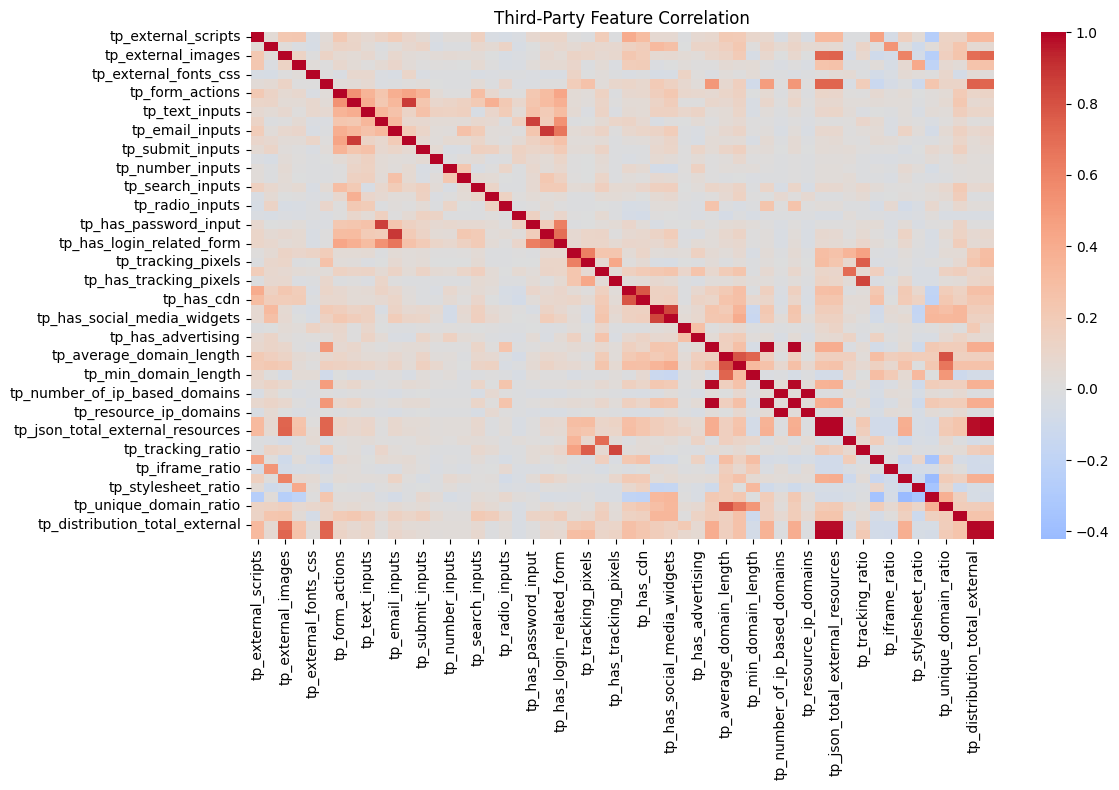


--- Feature Skewness ---


,feature,skewness,absolute_skewness
24,tp_tracking_pixels,27.494225,27.494225
31,tp_advertising_elements,26.740492,26.740492
23,tp_analytics_endpoints,19.000320,19.000320
33,tp_unique_third_party_domains,15.713264,15.713264
39,tp_resource_domains,15.688977,15.688977
37,tp_number_of_subdomains,15.647589,15.647589
14,tp_number_inputs,15.592835,15.592835
44,tp_tracking_ratio,14.895432,14.895432
4,tp_external_fonts_css,13.736201,13.736201
13,tp_button_inputs,12.930778,12.930778



THIRD-PARTY EDA COMPLETE
Total records: 762
Total numerical features: 59
Variable features: 54
Constant features: 5
EDA saved to: /content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features/eda/thirdparty


In [ ]:
# ================================================================
# CELL 18 — Third-Party EDA
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

TP_EDA_PATH = OUTPUT_PATH / "eda" / "thirdparty"
TP_EDA_PATH.mkdir(parents=True, exist_ok=True)

print("================================================")
print("THIRD-PARTY FEATURE EDA")
print("================================================")


# ------------------------------------------------
# 1. Numerical Features
# ------------------------------------------------

numeric_tp = df_tp_features.select_dtypes(
    include=[np.number]
).copy()

# Remove ID from statistical analysis
if "id" in numeric_tp.columns:
    numeric_tp = numeric_tp.drop(columns=["id"])


# ------------------------------------------------
# 2. Descriptive Statistics
# ------------------------------------------------

print("\n--- Third-Party Feature Summary ---")

tp_summary = numeric_tp.describe().T

display(tp_summary)

tp_summary.to_csv(
    TP_EDA_PATH / "thirdparty_feature_summary.csv"
)


# ------------------------------------------------
# 3. Non-Zero Feature Analysis
# ------------------------------------------------

nonzero_report = []

for column in numeric_tp.columns:

    nonzero_count = (numeric_tp[column] != 0).sum()

    nonzero_percentage = (
        nonzero_count / len(numeric_tp)
    ) * 100

    nonzero_report.append({
        "feature": column,
        "nonzero_count": nonzero_count,
        "zero_count": len(numeric_tp) - nonzero_count,
        "nonzero_percentage": nonzero_percentage
    })

df_tp_nonzero = pd.DataFrame(
    nonzero_report
).sort_values(
    "nonzero_percentage",
    ascending=False
)

print("\n--- Non-Zero Feature Analysis ---")

display(df_tp_nonzero)

df_tp_nonzero.to_csv(
    TP_EDA_PATH / "thirdparty_nonzero_report.csv",
    index=False
)


# ------------------------------------------------
# 4. Constant Features
# ------------------------------------------------

constant_features = []

for column in numeric_tp.columns:

    if numeric_tp[column].nunique(dropna=False) <= 1:

        constant_features.append({
            "feature": column,
            "unique_values": numeric_tp[column].nunique(
                dropna=False
            )
        })

df_tp_constant = pd.DataFrame(
    constant_features
)

print("\n--- Constant Features ---")

if df_tp_constant.empty:
    print("No constant features found.")

else:
    display(df_tp_constant)

    df_tp_constant.to_csv(
        TP_EDA_PATH / "thirdparty_constant_features.csv",
        index=False
    )


# ------------------------------------------------
# 5. Correlation Heatmap
# ------------------------------------------------

variable_features = [
    column
    for column in numeric_tp.columns
    if numeric_tp[column].nunique(dropna=False) > 1
]

if len(variable_features) >= 2:

    correlation_matrix = numeric_tp[
        variable_features
    ].corr()

    plt.figure(figsize=(12, 8))

    sns.heatmap(
        correlation_matrix,
        cmap="coolwarm",
        center=0,
        annot=False
    )

    plt.title(
        "Third-Party Feature Correlation"
    )

    plt.tight_layout()

    plt.savefig(
        TP_EDA_PATH / "tp_correlation_heatmap.png",
        dpi=150
    )

    plt.show()

    plt.close()


# ------------------------------------------------
# 6. Skewness Analysis
# ------------------------------------------------

skewness_report = []

for column in variable_features:

    skew_value = numeric_tp[column].skew()

    skewness_report.append({
        "feature": column,
        "skewness": skew_value,
        "absolute_skewness": abs(skew_value)
    })

df_tp_skew = pd.DataFrame(
    skewness_report
).sort_values(
    "absolute_skewness",
    ascending=False
)

print("\n--- Feature Skewness ---")

display(df_tp_skew)

df_tp_skew.to_csv(
    TP_EDA_PATH / "thirdparty_skewness_report.csv",
    index=False
)


# ------------------------------------------------
# 7. Final Summary
# ------------------------------------------------

print("\n================================================")
print("THIRD-PARTY EDA COMPLETE")
print("================================================")

print("Total records:", len(df_tp_features))

print(
    "Total numerical features:",
    len(numeric_tp.columns)
)

print(
    "Variable features:",
    len(variable_features)
)

print(
    "Constant features:",
    len(df_tp_constant)
)

print(
    "EDA saved to:",
    TP_EDA_PATH
)

print("================================================")

In [ ]:
THIRDPARTY_DROP = [
    # Constant
    "tp_external_fonts",
    "tp_javascript_frameworks",
    "tp_has_javascript_framework",
    "tp_security_risk_indicators",
    "tp_has_security_risk_indicator",

    # Redundant total-resource features
    "tp_calculated_external_resources",
    "tp_json_total_external_resources",
    "tp_distribution_total_external",

    # Redundant binary versions
    "tp_has_analytics",
    "tp_has_cdn",
    "tp_has_social_media_widgets",
    "tp_has_advertising",

    # Very sparse tracking
    "tp_tracking_pixels",
    "tp_has_tracking_pixels",
    "tp_tracking_ratio",

    # Very sparse input types
    "tp_number_inputs",
    "tp_tel_inputs",
    "tp_file_inputs",
    "tp_button_inputs",

    # Duplicate IP-domain feature
    "tp_resource_ip_domains"
]

df_tp_features = df_tp_features.drop(columns=THIRDPARTY_DROP, errors='ignore')

print("Features dropped.")
print(f"Updated df_tp_features shape: {df_tp_features.shape}")
display(df_tp_features.head())

Features dropped.
Updated df_tp_features shape: (762, 40)


,id,tp_external_scripts,tp_external_iframes,tp_external_images,tp_external_stylesheets,tp_external_fonts_css,tp_external_links,tp_form_actions,tp_form_inputs,tp_text_inputs,...,tp_resource_domains,tp_analytics_ratio,tp_script_ratio,tp_iframe_ratio,tp_image_ratio,tp_stylesheet_ratio,tp_link_ratio,tp_unique_domain_ratio,tp_internal_resources,tp_total_resource_urls
0,1,0,0,0,0,0,3,0,0,0,...,3,0.00,0.0,0.0,0.000000,0.000000,1.000000,1.333333,6.0,3
1,2,0,0,1,2,1,11,1,3,1,...,4,0.00,0.0,0.0,0.071429,0.142857,0.785714,1.000000,0.0,16
2,3,0,0,15,0,0,9,0,2,2,...,9,0.04,0.0,0.0,0.600000,0.000000,0.360000,1.000000,18.0,25
3,4,0,0,0,1,1,5,0,1,1,...,2,0.00,0.0,0.0,0.000000,0.166667,0.833333,1.000000,6.0,7
4,5,0,0,0,0,0,1,0,0,0,...,1,0.00,0.0,0.0,0.000000,0.000000,1.000000,1.000000,0.0,1


In [ ]:
#drop the col with zerocount more than 12
#Drop Col with Zero count more than 750
for col in df_tp_features.columns :
    if df_tp_features[col].eq(0).sum() > 750:
        df_tp_features.drop(col, axis=1, inplace=True)
df_tp_features


# Fill zero values with the mean of the column
# Mean includes the zero values

for col in df_tp_features.columns:

    if  col != 'id':

        # Mean = sum of ALL values / total number of values
        mean_value = df_tp_features[col].mean()

        # Replace 0 with the calculated mean
        df_tp_features.loc[
            df_tp_features[col] == 0, col
        ] = mean_value


# Display statistics

print(df_tp_features.eq(0).sum())
print(df_tp_features.isna().sum())
print(df_tp_features.info())
df_tp_features.describe().T


#save the df_tp_features
df_tp_features.to_csv(OUTPUT_PATH / "thirdparty_features.csv", index=False)



id                               0
tp_external_scripts              0
tp_external_iframes              0
tp_external_images               0
tp_external_stylesheets          0
tp_external_links                0
tp_form_actions                  0
tp_form_inputs                   0
tp_text_inputs                   0
tp_password_inputs               0
tp_email_inputs                  0
tp_hidden_inputs                 0
tp_submit_inputs                 0
tp_search_inputs                 0
tp_checkbox_inputs               0
tp_radio_inputs                  0
tp_has_password_input            0
tp_has_email_input               0
tp_has_login_related_form        0
tp_analytics_endpoints           0
tp_cdn_domains                   0
tp_social_media_widgets          0
tp_advertising_elements          0
tp_unique_third_party_domains    0
tp_average_domain_length         0
tp_max_domain_length             0
tp_min_domain_length             0
tp_number_of_subdomains          0
tp_resource_domains 

In [ ]:
# CELL 19 — Merge HTML + Text + Third-Party Features
print(f"Rows HTML: {len(df_html_features)}, Text: {len(df_text_features)}, Third-Party: {len(df_tp_features)}")

# Safely merging tables by explicit id
combined_features = df_html_features.merge(df_text_features, on='id', how='outer')
combined_features = combined_features.merge(df_tp_features, on='id', how='outer')

print(f"Merged shape: {combined_features.shape}")
print(f"Missing target indexes/Unmatched ID counts: {combined_features['id'].isnull().sum()}")

Rows HTML: 762, Text: 762, Third-Party: 762
Merged shape: (762, 508)
Missing target indexes/Unmatched ID counts: 0


In [ ]:
# CELL 20 — Missing/Infinite Value Processing
# Replace infs with NaN for uniform imputation
combined_features = combined_features.replace([np.inf, -np.inf], np.nan)

missing_report = combined_features.isnull().sum().reset_index()
missing_report.columns = ['feature', 'missing_count']
missing_report.to_csv(OUTPUT_PATH / "missing_feature_report.csv", index=False)

# Imputation strategy: median for numerical features
for col in combined_features.columns:
    if col != 'id':
        median_val = combined_features[col].median()
        # If median is nan (all values empty), impute with 0
        if pd.isna(median_val):
            median_val = 0
        combined_features[col] = combined_features[col].fillna(median_val)

print("Missing value recovery complete. Post-imputation check:", combined_features.isnull().sum().sum())

Missing value recovery complete. Post-imputation check: 0


In [ ]:
# CELL 21 — Constant/Duplicate Feature Removal
# Remove constant features
constant_cols = [col for col in combined_features.columns if col != 'id' and combined_features[col].nunique() <= 1]
pd.DataFrame({'constant_feature': constant_cols}).to_csv(OUTPUT_PATH / "constant_feature_report.csv", index=False)
combined_features = combined_features.drop(columns=constant_cols)

# Remove identical columns
duplicate_cols = []
numeric_cols = [col for col in combined_features.columns if col != 'id']
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        col1 = numeric_cols[i]
        col2 = numeric_cols[j]
        if col1 not in duplicate_cols and col2 not in duplicate_cols:
            if combined_features[col1].equals(combined_features[col2]):
                duplicate_cols.append(col2)

pd.DataFrame({'duplicate_feature': duplicate_cols}).to_csv(OUTPUT_PATH / "duplicate_feature_report.csv", index=False)
combined_features = combined_features.drop(columns=duplicate_cols)

print(f"Removed {len(constant_cols)} constant features and {len(duplicate_cols)} duplicate features.")

Removed 0 constant features and 3 duplicate features.


In [ ]:
# CELL 22 — Skewness Analysis & Transform
skewness = combined_features.select_dtypes(include=[np.number]).skew()
skewed_report = skewness[abs(skewness) > 1.5].reset_index()
skewed_report.columns = ['feature', 'skewness']
print("Highly skewed features (skew > 1.5):")
display(skewed_report.head(10))

# Log-transform highly skewed non-negative count/size columns
for col in skewed_report['feature']:
    if combined_features[col].min() >= 0:
        combined_features[f"{col}_log1p"] = np.log1p(combined_features[col])

print(f"Applied log1p transformations. Total dimensions: {combined_features.shape}")

Highly skewed features (skew > 1.5):


,feature,skewness
0,html_size_bytes,5.781240
1,html_character_count,5.635394
2,html_line_count,3.004412
3,html_number_of_tags,2.187338
4,html_number_of_attributes,2.631769
5,html_number_of_comments,12.393069
6,html_max_children,4.498511
7,html_average_children,-5.276669
8,html_number_of_forms,7.919355
9,html_number_of_inputs,6.434589


Applied log1p transformations. Total dimensions: (762, 613)


In [ ]:
# CELL 23 — Final Feature Validation
print("Validating clean numerical data matrix properties...")
# Ensure no non-numeric features exist besides 'id'
non_numeric = combined_features.drop(columns=['id']).select_dtypes(exclude=[np.number]).columns.tolist()
assert len(non_numeric) == 0, f"Found non-numeric features in ML dataset: {non_numeric}"
assert not combined_features.isnull().any().any(), "Detected unresolved NaNs!"
assert not np.isinf(combined_features.drop(columns=['id']).values).any(), "Detected unresolved Inf values!"
print("Validation Passed! Matrix is clean, structured, and entirely numerical.")

Validating clean numerical data matrix properties...
Validation Passed! Matrix is clean, structured, and entirely numerical.


In [ ]:
# CELL 24 — Save ML-Ready Feature Dataset
final_csv_path = OUTPUT_PATH / "combined_features.csv"
combined_features.to_csv(final_csv_path, index=False)
print(f"Successfully saved clean ML-ready dataset to: {final_csv_path}")

Successfully saved clean ML-ready dataset to: /content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features/combined_features.csv


In [ ]:
# CELL 25 — Display Final Feature Summary
print(f"--- FINAL DATASET OVERVIEW (Shape: {combined_features.shape}) ---")
display(combined_features.head())
print("\nDone processing. Ready for ingestion in subsequent ML models.")

--- FINAL DATASET OVERVIEW (Shape: (762, 613)) ---


,id,html_size_bytes,html_character_count,html_line_count,html_number_of_tags,html_number_of_unique_tags,html_number_of_attributes,html_number_of_comments,html_dom_depth,html_max_children,...,tp_number_of_subdomains_log1p,tp_resource_domains_log1p,tp_analytics_ratio_log1p,tp_script_ratio_log1p,tp_iframe_ratio_log1p,tp_image_ratio_log1p,tp_stylesheet_ratio_log1p,tp_unique_domain_ratio_log1p,tp_internal_resources_log1p,tp_total_resource_urls_log1p
0,1,39436.0,39394.0,406.0,323.0,33.0,623.0,75.661417,13.0,33.0,...,1.098612,1.386294,0.019708,0.133102,0.026283,0.135075,0.087448,0.847298,1.945910,1.386294
1,2,9793.0,9612.0,299.0,170.0,26.0,178.0,75.661417,12.0,47.0,...,1.609438,1.609438,0.019708,0.133102,0.026283,0.068993,0.133531,0.693147,5.005750,2.833213
2,3,158271.0,158036.0,623.0,402.0,31.0,1206.0,75.661417,21.0,45.0,...,2.302585,2.302585,0.039221,0.133102,0.026283,0.470004,0.087448,0.693147,2.944439,3.258097
3,4,5948.0,5941.0,253.0,57.0,17.0,84.0,1.000000,11.0,22.0,...,1.098612,1.098612,0.019708,0.133102,0.026283,0.135075,0.154151,0.693147,1.945910,2.079442
4,5,637.0,637.0,12.0,7.0,7.0,8.0,75.661417,3.0,2.0,...,0.693147,0.693147,0.019708,0.133102,0.026283,0.135075,0.087448,0.693147,5.005750,0.693147



Done processing. Ready for ingestion in subsequent ML models.


In [ ]:
print(CSV_PATH)
print(OUTPUT_PATH)
combined_features=pd.read_csv(OUTPUT_PATH / "combined_features.csv")
combined_features.columns



/content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/dataset.csv
/content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features


Index(['id', 'html_size_bytes', 'html_character_count', 'html_line_count',
       'html_number_of_tags', 'html_number_of_unique_tags',
       'html_number_of_attributes', 'html_number_of_comments',
       'html_dom_depth', 'html_max_children',
       ...
       'tp_number_of_subdomains_log1p', 'tp_resource_domains_log1p',
       'tp_analytics_ratio_log1p', 'tp_script_ratio_log1p',
       'tp_iframe_ratio_log1p', 'tp_image_ratio_log1p',
       'tp_stylesheet_ratio_log1p', 'tp_unique_domain_ratio_log1p',
       'tp_internal_resources_log1p', 'tp_total_resource_urls_log1p'],
      dtype='object', length=613)

In [ ]:
dff=pd.read_csv(CSV_PATH)
#see the count of each category in category column
category_counts = dff["illicit_activity_type"].value_counts()

print("--- Category Counts ---")
print(category_counts)


--- Category Counts ---
illicit_activity_type
Suspicious    364
Legitimate    351
Illegal        27
NSFW           15
Legal           3
suspicious      1
Phishing        1
Name: count, dtype: int64


In [ ]:
# Load the labels from the main dataset.csv
df_main_labels = pd.read_csv(CSV_PATH)[['id', 'risk', 'category', 'illicit_activity_type']]

# Merge these columns into combined_features based on 'id'
combined_features = combined_features.merge(df_main_labels, on='id', how='left')

# Save the updated combined features dataset back to disk
final_csv_path = OUTPUT_PATH / "combined_features.csv"
combined_features.to_csv(final_csv_path, index=False)

print(f"Successfully added labels to combined_features. New shape: {combined_features.shape}")
print("Columns added: ['risk', 'category', 'illicit_activity_type']")
display(combined_features[['id', 'risk', 'category', 'illicit_activity_type']].head())

Successfully added labels to combined_features. New shape: (762, 616)
Columns added: ['risk', 'category', 'illicit_activity_type']


,id,risk,category,illicit_activity_type
0,1,High,Scam,Suspicious
1,2,High,Scam,Suspicious
2,3,High,Scam,Suspicious
3,4,Safe,Business,Legitimate
4,5,Moderate,Tech,Suspicious


In [ ]:
combined_features.columns

Index(['id', 'html_size_bytes', 'html_character_count', 'html_line_count',
       'html_number_of_tags', 'html_number_of_unique_tags',
       'html_number_of_attributes', 'html_number_of_comments',
       'html_dom_depth', 'html_max_children',
       ...
       'tp_script_ratio_log1p', 'tp_iframe_ratio_log1p',
       'tp_image_ratio_log1p', 'tp_stylesheet_ratio_log1p',
       'tp_unique_domain_ratio_log1p', 'tp_internal_resources_log1p',
       'tp_total_resource_urls_log1p', 'risk', 'category',
       'illicit_activity_type'],
      dtype='object', length=616)

In [ ]:
# CELL 1 — Setup & Load Final Dataset

import pandas as pd
import numpy as np
import warnings
import joblib
import json
from pathlib import Path

# ML libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    cohen_kappa_score, matthews_corrcoef, log_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

# Boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Paths
OUTPUT_PATH = Path('/content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features')  # adjust if needed
MODELS_PATH = OUTPUT_PATH / 'models'
MODELS_PATH.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print(" STACKING ENSEMBLE PIPELINE")
print("=" * 70)
print(f"Random seed: {RANDOM_SEED}")
print(f"Output path: {OUTPUT_PATH}")

 STACKING ENSEMBLE PIPELINE
Random seed: 42
Output path: /content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features


In [ ]:
# ================================================================
# MODEL CELL 2 — LOAD FINAL DATASET
# ================================================================

df_final = pd.read_csv(
    OUTPUT_PATH / "combined_features.csv"
)

print("=" * 70)
print(" DATASET LOADED")
print("=" * 70)

print(f"Shape: {df_final.shape}")
print(f"Columns: {df_final.shape[1]}")

print("\nTarget columns:")

for col in [
    "risk",
    "category",
    "illicit_activity_type"
]:
    if col in df_final.columns:
        print(f"   ✓ {col}")
    else:
        print(f"   ✗ {col} NOT FOUND")

print("\nRisk distribution:")
print(df_final["risk"].value_counts())

print("\nCategory distribution:")
print(df_final["category"].value_counts())

print("\nIllicit activity distribution:")
print(df_final["illicit_activity_type"].value_counts())

 DATASET LOADED
Shape: (762, 616)
Columns: 616

Target columns:
   ✓ risk
   ✓ category
   ✓ illicit_activity_type

Risk distribution:
risk
Safe        351
Moderate    222
High        189
Name: count, dtype: int64

Category distribution:
category
Tech              219
Scam              110
Phishing           61
Social             51
E-commerce         45
Finance            42
News               39
Education          39
Government         35
Betting            29
Business           25
Entertainment      17
Adult              16
Malware            15
Domain Parking      7
Dating              3
Health              3
Other               2
Food                2
Travel              1
Malware             1
Name: count, dtype: int64

Illicit activity distribution:
illicit_activity_type
Suspicious    364
Legitimate    351
Illegal        27
NSFW           15
Legal           3
suspicious      1
Phishing        1
Name: count, dtype: int64


In [ ]:
RISK_COL = 'risk'
CATEGORY_COL = 'category'
ACTIVITY_COL = 'illicit_activity_type'

In [ ]:
# ================================================================
# MODEL CELL 3 — PREPARE FEATURES AND TARGETS
# ================================================================

print("=" * 70)
print(" PREPARING FEATURES AND TARGETS")
print("=" * 70)

RISK_COL = "risk"
CATEGORY_COL = "category"
ACTIVITY_COL = "illicit_activity_type"

# ------------------------------------------------
# Columns excluded from ML features
# ------------------------------------------------

EXCLUDE_COLS = [
    "id",
    "url",
    RISK_COL,
    CATEGORY_COL,
    ACTIVITY_COL
]

# ------------------------------------------------
# Features
# ------------------------------------------------

X = df_final.drop(
    columns=EXCLUDE_COLS,
    errors="ignore"
).copy()

# ------------------------------------------------
# Targets
# ------------------------------------------------

y_risk = df_final[RISK_COL].astype(str).copy()

y_category_original = (
    df_final[CATEGORY_COL]
    .astype(str)
    .copy()
)

y_activity = (
    df_final[ACTIVITY_COL]
    .astype(str)
    .copy()
)

# ------------------------------------------------
# Handle infinity
# ------------------------------------------------

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

# ------------------------------------------------
# Convert categorical feature columns
# ------------------------------------------------

categorical_feature_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

if categorical_feature_cols:

    print("\nCategorical feature columns:")
    print(categorical_feature_cols)

    X = pd.get_dummies(
        X,
        columns=categorical_feature_cols,
        drop_first=False,
        dtype=int
    )

# ------------------------------------------------
# Missing values
# ------------------------------------------------

X = X.fillna(0)

# ------------------------------------------------
# Final feature list
# ------------------------------------------------

feature_cols = X.columns.tolist()

print("\n" + "=" * 70)
print(" FINAL FEATURE MATRIX")
print("=" * 70)

print(f"Samples : {X.shape[0]}")
print(f"Features: {X.shape[1]}")

print(f"NaN: {X.isna().sum().sum()}")

print(
    "Inf:",
    np.isinf(
        X.select_dtypes(include=np.number)
    ).sum().sum()
)

 PREPARING FEATURES AND TARGETS

 FINAL FEATURE MATRIX
Samples : 762
Features: 612
NaN: 0
Inf: 0


In [ ]:
# ================================================================
# MODEL CELL 4 — TARGET ENCODING
# ================================================================

print("=" * 70)
print(" TARGET ENCODING")
print("=" * 70)


# ================================================================
# RISK
# ================================================================

risk_encoder = LabelEncoder()

y_risk_encoded = risk_encoder.fit_transform(
    y_risk
)


# ================================================================
# CATEGORY
# CATEGORY USES 5-FOLD CV
# ================================================================

MIN_CATEGORY_SAMPLES = 6

category_counts = (
    y_category_original
    .value_counts()
)

print("\n" + "=" * 70)
print(" ORIGINAL CATEGORY DISTRIBUTION")
print("=" * 70)

print(category_counts)

# ------------------------------------------------
# Find rare categories
# ------------------------------------------------

rare_categories = category_counts[
    category_counts < MIN_CATEGORY_SAMPLES
].index.tolist()

print("\nRare categories (< 6 samples):")

if rare_categories:
    for cls in rare_categories:
        print(
            f"   {cls}: "
            f"{category_counts[cls]} samples"
        )
else:
    print("   None")

# ------------------------------------------------
# Merge rare categories into Other
# ------------------------------------------------

y_category_model = y_category_original.apply(
    lambda x:
        "Other"
        if x in rare_categories
        else x
)

print("\n" + "=" * 70)
print(" CATEGORY AFTER RARE-CLASS HANDLING")
print("=" * 70)

print(
    y_category_model.value_counts()
)

# ------------------------------------------------
# Encode category
# ------------------------------------------------

category_encoder = LabelEncoder()

y_category_encoded = category_encoder.fit_transform(
    y_category_model
)


# ================================================================
# ILLICIT ACTIVITY
# NO CV
# ================================================================

activity_encoder = LabelEncoder()

y_activity_encoded = activity_encoder.fit_transform(
    y_activity
)


# ================================================================
# DISPLAY CLASSES
# ================================================================

print("\n" + "=" * 70)
print(" RISK CLASSES")
print("=" * 70)

for i, cls in enumerate(
    risk_encoder.classes_
):

    count = np.sum(
        y_risk_encoded == i
    )

    print(
        f"{i}: {cls} "
        f"({count} samples)"
    )


print("\n" + "=" * 70)
print(" CATEGORY CLASSES")
print("=" * 70)

for i, cls in enumerate(
    category_encoder.classes_
):

    count = np.sum(
        y_category_encoded == i
    )

    print(
        f"{i}: {cls} "
        f"({count} samples)"
    )


print("\n" + "=" * 70)
print(" ILLICIT ACTIVITY CLASSES")
print("=" * 70)

for i, cls in enumerate(
    activity_encoder.classes_
):

    count = np.sum(
        y_activity_encoded == i
    )

    print(
        f"{i}: {cls} "
        f"({count} samples)"
    )


# ================================================================
# SAVE ENCODERS
# ================================================================

joblib.dump(
    risk_encoder,
    MODELS_PATH / "risk_encoder.pkl"
)

joblib.dump(
    category_encoder,
    MODELS_PATH / "category_encoder.pkl"
)

joblib.dump(
    activity_encoder,
    MODELS_PATH / "activity_encoder.pkl"
)

print("\nEncoders saved successfully.")

 TARGET ENCODING

 ORIGINAL CATEGORY DISTRIBUTION
category
Tech              219
Scam              110
Phishing           61
Social             51
E-commerce         45
Finance            42
News               39
Education          39
Government         35
Betting            29
Business           25
Entertainment      17
Adult              16
Malware            15
Domain Parking      7
Dating              3
Health              3
Other               2
Food                2
Travel              1
Malware             1
Name: count, dtype: int64

Rare categories (< 6 samples):
   Dating: 3 samples
   Health: 3 samples
   Other: 2 samples
   Food: 2 samples
   Travel: 1 samples
   Malware : 1 samples

 CATEGORY AFTER RARE-CLASS HANDLING
category
Tech              219
Scam              110
Phishing           61
Social             51
E-commerce         45
Finance            42
News               39
Education          39
Government         35
Betting            29
Business           25
Entertai

In [ ]:
# ================================================================
# MODEL CELL 5 — 80/20 TRAIN-TEST SPLITS
# ================================================================

print("=" * 70)
print(" 80% TRAIN / 20% TEST SPLITS")
print("=" * 70)

TEST_SIZE = 0.2

# ================================================================
# RISK SPLIT
# ================================================================

X_risk_train, X_risk_test, \
y_risk_train, y_risk_test = train_test_split(

    X,
    y_risk_encoded,

    test_size=TEST_SIZE,

    random_state=RANDOM_SEED,

    stratify=y_risk_encoded
)


# ================================================================
# CATEGORY SPLIT
# ================================================================

X_cat_train, X_cat_test, \
y_cat_train, y_cat_test = train_test_split(

    X,
    y_category_encoded,

    test_size=TEST_SIZE,

    random_state=RANDOM_SEED,

    stratify=y_category_encoded
)


# ================================================================
# ACTIVITY SPLIT
# ================================================================

# Activity contains extremely rare classes.
# Therefore we do NOT use stratification here if any class
# has fewer than 2 samples.

activity_counts = pd.Series(
    y_activity_encoded
).value_counts()

if activity_counts.min() >= 2:

    X_activity_train, X_activity_test, \
    y_activity_train, y_activity_test = train_test_split(

        X,
        y_activity_encoded,

        test_size=TEST_SIZE,

        random_state=RANDOM_SEED,

        stratify=y_activity_encoded
    )

    activity_split_method = "Stratified 80/20"

else:

    X_activity_train, X_activity_test, \
    y_activity_train, y_activity_test = train_test_split(

        X,
        y_activity_encoded,

        test_size=TEST_SIZE,

        random_state=RANDOM_SEED
    )

    activity_split_method = "Random 80/20"


# ================================================================
# DISPLAY
# ================================================================

print("\nRISK")
print(
    f"Train: {len(X_risk_train)}"
)
print(
    f"Test : {len(X_risk_test)}"
)

print("\nCATEGORY")
print(
    f"Train: {len(X_cat_train)}"
)
print(
    f"Test : {len(X_cat_test)}"
)

print("\nILLICIT ACTIVITY")
print(
    f"Train: {len(X_activity_train)}"
)
print(
    f"Test : {len(X_activity_test)}"
)

print(
    f"\nActivity split: "
    f"{activity_split_method}"
)

 80% TRAIN / 20% TEST SPLITS

RISK
Train: 609
Test : 153

CATEGORY
Train: 609
Test : 153

ILLICIT ACTIVITY
Train: 609
Test : 153

Activity split: Random 80/20


In [ ]:
# ==============================================================
# CELL 7: CHECK CLASS DISTRIBUTION FOR 5-FOLD CV
# ==============================================================

import pandas as pd
import numpy as np

N_SPLITS = 5
MIN_SAMPLES_REQUIRED = N_SPLITS

print("=" * 70)
print("CHECKING CLASS DISTRIBUTION FOR 5-FOLD CROSS-VALIDATION")
print("=" * 70)


def check_cv_classes(y, target_name):
    counts = pd.Series(y).value_counts()

    print(f"\n{target_name}")
    print("-" * 70)
    print(f"Number of classes: {len(counts)}")
    print(f"Minimum class count: {counts.min()}")
    print(f"Maximum class count: {counts.max()}")

    rare_classes = counts[counts < MIN_SAMPLES_REQUIRED]

    if len(rare_classes) == 0:
        print(f"OK: Every class has at least {N_SPLITS} samples.")
    else:
        print(
            f"WARNING: {len(rare_classes)} class(es) "
            f"have fewer than {N_SPLITS} samples."
        )

        print("\nRare classes:")
        print(rare_classes)

    return counts, rare_classes


risk_counts, risk_rare = check_cv_classes(
    y_risk,
    "RISK"
)

category_counts, category_rare = check_cv_classes(
    y_category_encoded,
    "CATEGORY"
)

activity_counts, activity_rare = check_cv_classes(
    y_activity,
    "ILLICIT ACTIVITY"
)

CHECKING CLASS DISTRIBUTION FOR 5-FOLD CROSS-VALIDATION

RISK
----------------------------------------------------------------------
Number of classes: 3
Minimum class count: 189
Maximum class count: 351
OK: Every class has at least 5 samples.

CATEGORY
----------------------------------------------------------------------
Number of classes: 16
Minimum class count: 7
Maximum class count: 219
OK: Every class has at least 5 samples.

ILLICIT ACTIVITY
----------------------------------------------------------------------
Number of classes: 7
Minimum class count: 1
Maximum class count: 364

Rare classes:
illicit_activity_type
Legal         3
suspicious    1
Phishing      1
Name: count, dtype: int64


In [ ]:
# ==============================================================
# CELL 7B: HANDLE EXTREMELY RARE CLASSES
# ==============================================================

MIN_SAMPLES_REQUIRED = 5


def merge_rare_classes(y, min_samples=5, other_label="Other"):

    y_series = pd.Series(y).copy()

    class_counts = y_series.value_counts()

    rare_classes = class_counts[
        class_counts < min_samples
    ].index

    y_series = y_series.apply(
        lambda x: other_label if x in rare_classes else x
    )

    return y_series


# --------------------------------------------------------------
# CATEGORY
# --------------------------------------------------------------

y_category_cv = merge_rare_classes(
    y_category_encoded,
    min_samples=MIN_SAMPLES_REQUIRED
)


# --------------------------------------------------------------
# ILLICIT ACTIVITY
# --------------------------------------------------------------

y_activity_cv = merge_rare_classes(
    y_activity,
    min_samples=MIN_SAMPLES_REQUIRED
)


print("=" * 70)
print("CLASS DISTRIBUTION AFTER RARE-CLASS HANDLING")
print("=" * 70)

print("\nCATEGORY")
print(y_category_cv.value_counts())

print("\nILLICIT ACTIVITY")
print(y_activity_cv.value_counts())


# Verify again
print("\n" + "=" * 70)
print("5-FOLD CV CHECK")
print("=" * 70)

print(
    "\nCategory minimum count:",
    y_category_cv.value_counts().min()
)

print(
    "Activity minimum count:",
    y_activity_cv.value_counts().min()
)

CLASS DISTRIBUTION AFTER RARE-CLASS HANDLING

CATEGORY
15    219
13    110
12     61
14     51
4      45
7      42
10     39
5      39
8      35
1      29
2      25
6      17
0      16
9      15
11     12
3       7
Name: count, dtype: int64

ILLICIT ACTIVITY
illicit_activity_type
Suspicious    364
Legitimate    351
Illegal        27
NSFW           15
Other           5
Name: count, dtype: int64

5-FOLD CV CHECK

Category minimum count: 7
Activity minimum count: 5


In [ ]:
# ================================================================
# CELL 8 — 5-FOLD CROSS-VALIDATION CONFIGURATION
# ================================================================

cv_risk = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

cv_category = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

cv_activity = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

print("=" * 70)
print(" 5-FOLD CROSS-VALIDATION READY")
print("=" * 70)

print("\nEach target will use:")
print("   Fold 1")
print("   Fold 2")
print("   Fold 3")
print("   Fold 4")
print("   Fold 5")

print("\nThe 20% test set remains untouched.")

 5-FOLD CROSS-VALIDATION READY

Each target will use:
   Fold 1
   Fold 2
   Fold 3
   Fold 4
   Fold 5

The 20% test set remains untouched.


In [ ]:
# ================================================================
# CELL 9 — BASE MODELS FOR RISK
# ================================================================

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

print("=" * 70)
print(" DEFINING BASE MODELS — RISK")
print("=" * 70)

xgb_risk = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_SEED,
    eval_metric="mlogloss",
    n_jobs=-1,
    verbosity=0
)

rf_risk = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight="balanced"
)

lgbm_risk = LGBMClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)

base_models_risk = {
    "XGBoost": xgb_risk,
    "RandomForest": rf_risk,
    "LightGBM": lgbm_risk
}

print("\nBase models:")
for name in base_models_risk:
    print(f"   • {name}")

 DEFINING BASE MODELS — RISK

Base models:
   • XGBoost
   • RandomForest
   • LightGBM


In [ ]:
# ================================================================
# MODEL CELL 7 — RISK: 5-FOLD CV + TEST
# ================================================================
from sklearn.base import clone
print("=" * 70)
print(" RISK — 5-FOLD CV + INDEPENDENT TEST")
print("=" * 70)

risk_results = {}

for name, model in base_models_risk.items():

    print(f"\n{'=' * 60}")
    print(name)
    print(f"{'=' * 60}")

    fold_acc = []
    fold_f1 = []

    for fold, (
        train_idx,
        val_idx
    ) in enumerate(
        cv_risk.split(
            X_risk_train,
            y_risk_train
        ),
        start=1
    ):

        X_fold_train = X_risk_train.iloc[
            train_idx
        ]

        X_fold_val = X_risk_train.iloc[
            val_idx
        ]

        y_fold_train = y_risk_train[
            train_idx
        ]

        y_fold_val = y_risk_train[
            val_idx
        ]

        fold_model = clone(model)

        fold_model.fit(
            X_fold_train,
            y_fold_train
        )

        y_fold_pred = fold_model.predict(
            X_fold_val
        )

        acc = accuracy_score(
            y_fold_val,
            y_fold_pred
        )

        f1 = f1_score(
            y_fold_val,
            y_fold_pred,
            average="macro"
        )

        fold_acc.append(acc)
        fold_f1.append(f1)

        print(
            f"Fold {fold}: "
            f"Accuracy={acc:.4f} | "
            f"Macro F1={f1:.4f}"
        )

    # ------------------------------------------------
    # CV statistics
    # ------------------------------------------------

    mean_cv_acc = np.mean(fold_acc)
    std_cv_acc = np.std(fold_acc)

    mean_cv_f1 = np.mean(fold_f1)
    std_cv_f1 = np.std(fold_f1)

    # ------------------------------------------------
    # Final model
    # ------------------------------------------------

    final_model = clone(model)

    final_model.fit(
        X_risk_train,
        y_risk_train
    )

    # ------------------------------------------------
    # Independent test
    # ------------------------------------------------

    y_test_pred = final_model.predict(
        X_risk_test
    )

    test_acc = accuracy_score(
        y_risk_test,
        y_test_pred
    )

    test_f1 = f1_score(
        y_risk_test,
        y_test_pred,
        average="macro"
    )

    risk_results[name] = {

         "model": final_model,

         "cv_accuracy_mean": mean_cv_acc,
         "cv_accuracy_std": std_cv_acc,

         "cv_f1_mean": mean_cv_f1,
         "cv_f1_std": std_cv_f1,

         "test_accuracy": test_acc,
         "test_f1": test_f1
    }

    print(
        f"\nCV Accuracy: "
        f"{mean_cv_acc:.4f} ± {std_cv_acc:.4f}"
    )

    print(
        f"CV Macro F1: "
        f"{mean_cv_f1:.4f} ± {std_cv_f1:.4f}"
    )

    print(
        f"Test Accuracy: "
        f"{test_acc:.4f}"
    )

    print(
        f"Test Macro F1: "
        f"{test_f1:.4f}"
    )


risk_summary_df = pd.DataFrame({
    name: {
        "CV Accuracy Mean":
            result["cv_accuracy_mean"],

        "CV Accuracy Std":
            result["cv_accuracy_std"],

        "CV Macro F1 Mean":
            result["cv_f1_mean"],

        "CV Macro F1 Std":
            result["cv_f1_std"],

        "Test Accuracy":
            result["test_accuracy"],

        "Test Macro F1":
            result["test_f1"]
    }
    for name, result
    in risk_results.items()
}).T

display(
    risk_summary_df.round(4)
)

 RISK — 5-FOLD CV + INDEPENDENT TEST

XGBoost
Fold 1: Accuracy=0.6557 | Macro F1=0.6223
Fold 2: Accuracy=0.6393 | Macro F1=0.5884
Fold 3: Accuracy=0.6311 | Macro F1=0.5903
Fold 4: Accuracy=0.6557 | Macro F1=0.6074
Fold 5: Accuracy=0.5950 | Macro F1=0.5780

CV Accuracy: 0.6354 ± 0.0223
CV Macro F1: 0.5973 ± 0.0157
Test Accuracy: 0.6797
Test Macro F1: 0.6490

RandomForest
Fold 1: Accuracy=0.5902 | Macro F1=0.5451
Fold 2: Accuracy=0.5656 | Macro F1=0.4899
Fold 3: Accuracy=0.6066 | Macro F1=0.5413
Fold 4: Accuracy=0.6230 | Macro F1=0.5437
Fold 5: Accuracy=0.5785 | Macro F1=0.5364

CV Accuracy: 0.5928 ± 0.0203
CV Macro F1: 0.5313 ± 0.0209
Test Accuracy: 0.6340
Test Macro F1: 0.5884

LightGBM
Fold 1: Accuracy=0.6148 | Macro F1=0.5801
Fold 2: Accuracy=0.5902 | Macro F1=0.5565
Fold 3: Accuracy=0.6230 | Macro F1=0.5883
Fold 4: Accuracy=0.6721 | Macro F1=0.6300
Fold 5: Accuracy=0.5868 | Macro F1=0.5561

CV Accuracy: 0.6174 ± 0.0307
CV Macro F1: 0.5822 ± 0.0271
Test Accuracy: 0.6732
Test Macro F1

,CV Accuracy Mean,CV Accuracy Std,CV Macro F1 Mean,CV Macro F1 Std,Test Accuracy,Test Macro F1
XGBoost,0.6354,0.0223,0.5973,0.0157,0.6797,0.6490
RandomForest,0.5928,0.0203,0.5313,0.0209,0.6340,0.5884
LightGBM,0.6174,0.0307,0.5822,0.0271,0.6732,0.6359


In [ ]:
# ================================================================
# CELL 11 — BASE MODELS FOR CATEGORY
# ================================================================

print("=" * 70)
print(" DEFINING BASE MODELS — CATEGORY")
print("=" * 70)

xgb_cat = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_SEED,
    eval_metric="mlogloss",
    n_jobs=-1,
    verbosity=0
)

rf_cat = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight="balanced"
)

lgbm_cat = LGBMClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)

base_models_cat = {
    "XGBoost": xgb_cat,
    "RandomForest": rf_cat,
    "LightGBM": lgbm_cat
}

print("\nBase models:")
for name in base_models_cat:
    print(f"   • {name}")

 DEFINING BASE MODELS — CATEGORY

Base models:
   • XGBoost
   • RandomForest
   • LightGBM


In [ ]:
# ================================================================
# MODEL CELL 8 — CATEGORY: 5-FOLD CV + TEST
# ================================================================

print("=" * 70)
print(" CATEGORY — 5-FOLD CV + INDEPENDENT TEST")
print("=" * 70)

category_results = {}

for name, model in base_models_cat.items():

    print(f"\n{'=' * 60}")
    print(name)
    print(f"{'=' * 60}")

    fold_acc = []
    fold_f1 = []

    for fold, (
        train_idx,
        val_idx
    ) in enumerate(
        cv_category.split(
            X_cat_train,
            y_cat_train
        ),
        start=1
    ):

        X_fold_train = X_cat_train.iloc[
            train_idx
        ]

        X_fold_val = X_cat_train.iloc[
            val_idx
        ]

        y_fold_train = y_cat_train[
            train_idx
        ]

        y_fold_val = y_cat_train[
            val_idx
        ]

        fold_model = clone(model)

        fold_model.fit(
            X_fold_train,
            y_fold_train
        )

        y_fold_pred = fold_model.predict(
            X_fold_val
        )

        acc = accuracy_score(
            y_fold_val,
            y_fold_pred
        )

        f1 = f1_score(
            y_fold_val,
            y_fold_pred,
            average="macro"
        )

        fold_acc.append(acc)
        fold_f1.append(f1)

        print(
            f"Fold {fold}: "
            f"Accuracy={acc:.4f} | "
            f"Macro F1={f1:.4f}"
        )

    # ------------------------------------------------
    # CV statistics
    # ------------------------------------------------

    mean_cv_acc = np.mean(fold_acc)
    std_cv_acc = np.std(fold_acc)

    mean_cv_f1 = np.mean(fold_f1)
    std_cv_f1 = np.std(fold_f1)

    # ------------------------------------------------
    # Final model
    # ------------------------------------------------

    final_model = clone(model)

    final_model.fit(
        X_cat_train,
        y_cat_train
    )

    # ------------------------------------------------
    # Independent test
    # ------------------------------------------------

    y_test_pred = final_model.predict(
        X_cat_test
    )

    test_acc = accuracy_score(
        y_cat_test,
        y_test_pred
    )

    test_f1 = f1_score(
        y_cat_test,
        y_test_pred,
        average="macro"
    )

    category_results[name] = {

        "model": final_model,

        "cv_accuracy_mean": mean_cv_acc,
        "cv_accuracy_std": std_cv_acc,

        "cv_f1_mean": mean_cv_f1,
        "cv_f1_std": std_cv_f1,

        "test_accuracy": test_acc,
        "test_f1": test_f1
    }

    print(
        f"\nCV Accuracy: "
        f"{mean_cv_acc:.4f} ± {std_cv_acc:.4f}"
    )

    print(
        f"CV Macro F1: "
        f"{mean_cv_f1:.4f} ± {std_cv_f1:.4f}"
    )

    print(
        f"Test Accuracy: "
        f"{test_acc:.4f}"
    )

    print(
        f"Test Macro F1: "
        f"{test_f1:.4f}"
    )


category_summary_df = pd.DataFrame({
    name: {
        "CV Accuracy Mean":
            result["cv_accuracy_mean"],

        "CV Accuracy Std":
            result["cv_accuracy_std"],

        "CV Macro F1 Mean":
            result["cv_f1_mean"],

        "CV Macro F1 Std":
            result["cv_f1_std"],

        "Test Accuracy":
            result["test_accuracy"],

        "Test Macro F1":
            result["test_f1"]
    }
    for name, result in category_results.items()
}).T

display(
    category_summary_df.round(4)
)

 CATEGORY — 5-FOLD CV + INDEPENDENT TEST

XGBoost
Fold 1: Accuracy=0.5328 | Macro F1=0.5300
Fold 2: Accuracy=0.4754 | Macro F1=0.3390
Fold 3: Accuracy=0.5246 | Macro F1=0.4941
Fold 4: Accuracy=0.5410 | Macro F1=0.4727
Fold 5: Accuracy=0.4711 | Macro F1=0.4061

CV Accuracy: 0.5090 ± 0.0297
CV Macro F1: 0.4484 ± 0.0680
Test Accuracy: 0.5359
Test Macro F1: 0.4725

RandomForest
Fold 1: Accuracy=0.5410 | Macro F1=0.5346
Fold 2: Accuracy=0.4672 | Macro F1=0.3410
Fold 3: Accuracy=0.5246 | Macro F1=0.4783
Fold 4: Accuracy=0.4754 | Macro F1=0.4009
Fold 5: Accuracy=0.4959 | Macro F1=0.4498

CV Accuracy: 0.5008 ± 0.0282
CV Macro F1: 0.4409 ± 0.0661
Test Accuracy: 0.5752
Test Macro F1: 0.5088

LightGBM
Fold 1: Accuracy=0.5492 | Macro F1=0.5630
Fold 2: Accuracy=0.4754 | Macro F1=0.3226
Fold 3: Accuracy=0.4836 | Macro F1=0.4666
Fold 4: Accuracy=0.5246 | Macro F1=0.4350
Fold 5: Accuracy=0.4628 | Macro F1=0.4028

CV Accuracy: 0.4991 ± 0.0325
CV Macro F1: 0.4380 ± 0.0787
Test Accuracy: 0.5425
Test Macr

,CV Accuracy Mean,CV Accuracy Std,CV Macro F1 Mean,CV Macro F1 Std,Test Accuracy,Test Macro F1
XGBoost,0.5090,0.0297,0.4484,0.0680,0.5359,0.4725
RandomForest,0.5008,0.0282,0.4409,0.0661,0.5752,0.5088
LightGBM,0.4991,0.0325,0.4380,0.0787,0.5425,0.4990


In [ ]:
# ================================================================
# CELL 13 — BASE MODELS FOR ILLICIT ACTIVITY
# ================================================================

print("=" * 70)
print(" DEFINING BASE MODELS — ILLICIT ACTIVITY")
print("=" * 70)

xgb_activity = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_SEED,
    eval_metric="mlogloss",
    n_jobs=-1,
    verbosity=0
)

rf_activity = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight="balanced"
)

lgbm_activity = LGBMClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)

base_models_activity = {
    "XGBoost": xgb_activity,
    "RandomForest": rf_activity,
    "LightGBM": lgbm_activity
}

print("\nBase models:")
for name in base_models_activity:
    print(f"   • {name}")

 DEFINING BASE MODELS — ILLICIT ACTIVITY

Base models:
   • XGBoost
   • RandomForest
   • LightGBM


In [ ]:
# ================================================================
# MODEL CELL 9 — ILLICIT ACTIVITY: DIRECT TRAIN + TEST
# NO CROSS-VALIDATION
# ================================================================

print("=" * 70)
print(" ILLICIT ACTIVITY — DIRECT TRAIN + TEST")
print(" NO CROSS-VALIDATION")
print("=" * 70)

activity_results = {}

for name, model in base_models_activity.items():

    print(f"\n{'=' * 60}")
    print(name)
    print(f"{'=' * 60}")

    final_model = clone(model)

    # ------------------------------------------------
    # Train
    # ------------------------------------------------

    final_model.fit(
        X_activity_train,
        y_activity_train
    )

    # ------------------------------------------------
    # Test
    # ------------------------------------------------

    y_test_pred = final_model.predict(
        X_activity_test
    )

    test_acc = accuracy_score(
        y_activity_test,
        y_test_pred
    )

    test_f1 = f1_score(
        y_activity_test,
        y_test_pred,
        average="macro"
    )

    activity_results[name] = {

        "model": final_model,

        "test_accuracy": test_acc,

        "test_f1": test_f1
    }

    print(
        f"Test Accuracy: "
        f"{test_acc:.4f}"
    )

    print(
        f"Test Macro F1: "
        f"{test_f1:.4f}"
    )


activity_summary_df = pd.DataFrame({
    name: {
        "Test Accuracy":
            result["test_accuracy"],

        "Test Macro F1":
            result["test_f1"]
    }
    for name, result in activity_results.items()
}).T

print("\n" + "=" * 70)
print(" ILLICIT ACTIVITY SUMMARY")
print("=" * 70)

display(
    activity_summary_df.round(4)
)

 ILLICIT ACTIVITY — DIRECT TRAIN + TEST
 NO CROSS-VALIDATION

XGBoost
Test Accuracy: 0.6993
Test Macro F1: 0.7293

RandomForest
Test Accuracy: 0.6797
Test Macro F1: 0.5918

LightGBM
Test Accuracy: 0.7190
Test Macro F1: 0.7393

 ILLICIT ACTIVITY SUMMARY


,Test Accuracy,Test Macro F1
XGBoost,0.6993,0.7293
RandomForest,0.6797,0.5918
LightGBM,0.7190,0.7393


In [ ]:
# ================================================================
# CELL 15 — STACKING ENSEMBLE — RISK
# ================================================================

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

print("=" * 70)
print(" BUILDING STACKING ENSEMBLE — RISK")
print("=" * 70)

# ------------------------------------------------
# Meta learner
# ------------------------------------------------

meta_learner_risk = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# ------------------------------------------------
# Stacking model
# ------------------------------------------------

stacking_risk = StackingClassifier(

    estimators=[

        (
            "xgb",
            clone(xgb_risk)
        ),

        (
            "rf",
            clone(rf_risk)
        ),

        (
            "lgbm",
            clone(lgbm_risk)
        )
    ],

    final_estimator=meta_learner_risk,

    # 5-fold CV generates out-of-fold meta-features
    cv=cv_risk,

    stack_method="predict_proba",

    n_jobs=-1,

    passthrough=False
)

# ------------------------------------------------
# Train
# ------------------------------------------------

print("\nTraining stacking ensemble...")

stacking_risk.fit(
    X_risk_train,
    y_risk_train
)

# ------------------------------------------------
# Predictions
# ------------------------------------------------

y_pred_test_risk = stacking_risk.predict(
    X_risk_test
)

# ------------------------------------------------
# Test metrics
# ------------------------------------------------

risk_stack_test_acc = accuracy_score(
    y_risk_test,
    y_pred_test_risk
)

risk_stack_test_f1 = f1_score(
    y_risk_test,
    y_pred_test_risk,
    average="macro"
)

print("\nSTACKING RESULTS — RISK")
print("=" * 70)

print(
    f"Test Accuracy: "
    f"{risk_stack_test_acc:.4f}"
)

print(
    f"Test Macro F1: "
    f"{risk_stack_test_f1:.4f}"
)

# ------------------------------------------------
# Save
# ------------------------------------------------

joblib.dump(
    stacking_risk,
    MODELS_PATH / "stacking_risk.pkl"
)

print(
    f"\nSaved: "
    f"{MODELS_PATH / 'stacking_risk.pkl'}"
)

 BUILDING STACKING ENSEMBLE — RISK

Training stacking ensemble...

STACKING RESULTS — RISK
Test Accuracy: 0.6863
Test Macro F1: 0.6509

Saved: /content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features/models/stacking_risk.pkl


In [ ]:
# ================================================================
# CELL 16 — STACKING ENSEMBLE — CATEGORY (NO INTERNAL CV)
# ================================================================

from sklearn.preprocessing import LabelEncoder

print("=" * 70)
print(" BUILDING STACKING ENSEMBLE — CATEGORY")
print("=" * 70)

# ------------------------------------------------
# Re-encode Target to Ensure Contiguous Labels [0, N-1]
# ------------------------------------------------
stack_cat_encoder = LabelEncoder()
y_cat_train_encoded = stack_cat_encoder.fit_transform(y_cat_train)

# Map test target securely
y_cat_test_encoded = []
for val in y_cat_test:
    if val in stack_cat_encoder.classes_:
        y_cat_test_encoded.append(stack_cat_encoder.transform([val])[0])
    else:
        y_cat_test_encoded.append(0)
y_cat_test_encoded = np.array(y_cat_test_encoded)

# ================================================================
# MODEL CELL 11 — CATEGORY STACKING
# ================================================================

meta_learner_category = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=RANDOM_SEED
)

stacking_category = StackingClassifier(

    estimators=[
        (
            "xgb",
            clone(xgb_cat)
        ),
        (
            "rf",
            clone(rf_cat)
        ),
        (
            "lgbm",
            clone(lgbm_cat)
        )
    ],

    final_estimator=meta_learner_category,

    cv=cv_category,

    stack_method="predict_proba",

    n_jobs=-1,

    passthrough=False
)

print("Training Category stacking...")

stacking_category.fit(
    X_cat_train,
    y_cat_train
)

y_pred_test_category = (
    stacking_category.predict(
        X_cat_test
    )
)

category_stack_test_acc = accuracy_score(
    y_cat_test,
    y_pred_test_category
)

category_stack_test_f1 = f1_score(
    y_cat_test,
    y_pred_test_category,
    average="macro"
)

print("\nCATEGORY STACKING")
print("=" * 70)

print(
    f"Test Accuracy: "
    f"{category_stack_test_acc:.4f}"
)

print(
    f"Test Macro F1: "
    f"{category_stack_test_f1:.4f}"
)

joblib.dump(
    stacking_category,
    MODELS_PATH / "stacking_category.pkl"
)

 BUILDING STACKING ENSEMBLE — CATEGORY
Training Category stacking...

CATEGORY STACKING
Test Accuracy: 0.5294
Test Macro F1: 0.4537


['/content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features/models/stacking_category.pkl']

In [ ]:
# ================================================================
# MODEL CELL 12 — ILLICIT ACTIVITY SOFT VOTING
# NO CROSS-VALIDATION
# ================================================================

from sklearn.ensemble import VotingClassifier

print("=" * 70)
print(" ILLICIT ACTIVITY — SOFT VOTING ENSEMBLE")
print(" NO CROSS-VALIDATION")
print("=" * 70)

voting_activity = VotingClassifier(

    estimators=[
        (
            "xgb",
            clone(xgb_activity)
        ),
        (
            "rf",
            clone(rf_activity)
        ),
        (
            "lgbm",
            clone(lgbm_activity)
        )
    ],

    voting="soft",

    n_jobs=-1
)

print("\nTraining Activity voting ensemble...")

voting_activity.fit(
    X_activity_train,
    y_activity_train
)

y_pred_test_activity = (
    voting_activity.predict(
        X_activity_test
    )
)

activity_stack_test_acc = accuracy_score(
    y_activity_test,
    y_pred_test_activity
)

activity_stack_test_f1 = f1_score(
    y_activity_test,
    y_pred_test_activity,
    average="macro"
)

print("\nILLICIT ACTIVITY ENSEMBLE")
print("=" * 70)

print(
    f"Test Accuracy: "
    f"{activity_stack_test_acc:.4f}"
)

print(
    f"Test Macro F1: "
    f"{activity_stack_test_f1:.4f}"
)

joblib.dump(
    voting_activity,
    MODELS_PATH / "activity_voting.pkl"
)

 ILLICIT ACTIVITY — SOFT VOTING ENSEMBLE
 NO CROSS-VALIDATION

Training Activity voting ensemble...

ILLICIT ACTIVITY ENSEMBLE
Test Accuracy: 0.6993
Test Macro F1: 0.5997


['/content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features/models/activity_voting.pkl']

In [ ]:
# ================================================================
# MODEL CELL 13 — FINAL MODEL COMPARISON
# ================================================================

print("=" * 70)
print(" FINAL MODEL COMPARISON")
print("=" * 70)


# ================================================================
# RISK
# ================================================================

risk_final = pd.DataFrame({

    "Model": [
        "XGBoost",
        "RandomForest",
        "LightGBM",
        "Stacking"
    ],

    "CV Accuracy": [
        risk_results["XGBoost"]["cv_accuracy_mean"],
        risk_results["RandomForest"]["cv_accuracy_mean"],
        risk_results["LightGBM"]["cv_accuracy_mean"],
        np.nan
    ],

    "CV Macro F1": [
        risk_results["XGBoost"]["cv_f1_mean"],
        risk_results["RandomForest"]["cv_f1_mean"],
        risk_results["LightGBM"]["cv_f1_mean"],
        np.nan
    ],

    "Test Accuracy": [
        risk_results["XGBoost"]["test_accuracy"],
        risk_results["RandomForest"]["test_accuracy"],
        risk_results["LightGBM"]["test_accuracy"],
        risk_stack_test_acc
    ],

    "Test Macro F1": [
        risk_results["XGBoost"]["test_f1"],
        risk_results["RandomForest"]["test_f1"],
        risk_results["LightGBM"]["test_f1"],
        risk_stack_test_f1
    ]
})


# ================================================================
# CATEGORY
# ================================================================

category_final = pd.DataFrame({

    "Model": [
        "XGBoost",
        "RandomForest",
        "LightGBM",
        "Stacking"
    ],

    "CV Accuracy": [
        category_results["XGBoost"]["cv_accuracy_mean"],
        category_results["RandomForest"]["cv_accuracy_mean"],
        category_results["LightGBM"]["cv_accuracy_mean"],
        np.nan
    ],

    "CV Macro F1": [
        category_results["XGBoost"]["cv_f1_mean"],
        category_results["RandomForest"]["cv_f1_mean"],
        category_results["LightGBM"]["cv_f1_mean"],
        np.nan
    ],

    "Test Accuracy": [
        category_results["XGBoost"]["test_accuracy"],
        category_results["RandomForest"]["test_accuracy"],
        category_results["LightGBM"]["test_accuracy"],
        category_stack_test_acc
    ],

    "Test Macro F1": [
        category_results["XGBoost"]["test_f1"],
        category_results["RandomForest"]["test_f1"],
        category_results["LightGBM"]["test_f1"],
        category_stack_test_f1
    ]
})


# ================================================================
# ILLICIT ACTIVITY
# ================================================================

activity_final = pd.DataFrame({

    "Model": [
        "XGBoost",
        "RandomForest",
        "LightGBM",
        "Soft Voting"
    ],

    "CV Accuracy": [
        np.nan,
        np.nan,
        np.nan,
        np.nan
    ],

    "CV Macro F1": [
        np.nan,
        np.nan,
        np.nan,
        np.nan
    ],

    "Test Accuracy": [
        activity_results["XGBoost"]["test_accuracy"],
        activity_results["RandomForest"]["test_accuracy"],
        activity_results["LightGBM"]["test_accuracy"],
        activity_stack_test_acc
    ],

    "Test Macro F1": [
        activity_results["XGBoost"]["test_f1"],
        activity_results["RandomForest"]["test_f1"],
        activity_results["LightGBM"]["test_f1"],
        activity_stack_test_f1
    ]
})


print("\nRISK")
display(risk_final.round(4))

print("\nCATEGORY")
display(category_final.round(4))

print("\nILLICIT ACTIVITY")
display(activity_final.round(4))

 FINAL MODEL COMPARISON

RISK


,Model,CV Accuracy,CV Macro F1,Test Accuracy,Test Macro F1
0,XGBoost,0.6354,0.5973,0.6797,0.6490
1,RandomForest,0.5928,0.5313,0.6340,0.5884
2,LightGBM,0.6174,0.5822,0.6732,0.6359
3,Stacking,NaN,NaN,0.6863,0.6509



CATEGORY


,Model,CV Accuracy,CV Macro F1,Test Accuracy,Test Macro F1
0,XGBoost,0.5090,0.4484,0.5359,0.4725
1,RandomForest,0.5008,0.4409,0.5752,0.5088
2,LightGBM,0.4991,0.4380,0.5425,0.4990
3,Stacking,NaN,NaN,0.5294,0.4537



ILLICIT ACTIVITY


,Model,CV Accuracy,CV Macro F1,Test Accuracy,Test Macro F1
0,XGBoost,NaN,NaN,0.6993,0.7293
1,RandomForest,NaN,NaN,0.6797,0.5918
2,LightGBM,NaN,NaN,0.7190,0.7393
3,Soft Voting,NaN,NaN,0.6993,0.5997


In [ ]:
# ================================================================
# MODEL CELL 14 — RISK CLASSIFICATION REPORT
# ================================================================

print("=" * 70)
print(" RISK CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_risk_test,
        y_pred_test_risk,
        target_names=risk_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

cm_risk = confusion_matrix(
    y_risk_test,
    y_pred_test_risk
)

cm_risk_df = pd.DataFrame(
    cm_risk,
    index=[
        f"True_{c}"
        for c in risk_encoder.classes_
    ],
    columns=[
        f"Pred_{c}"
        for c in risk_encoder.classes_
    ]
)

print("\nConfusion Matrix:")
display(cm_risk_df)

print("\nAdditional Metrics:")

print(
    f"Cohen's Kappa: "
    f"{cohen_kappa_score(y_risk_test, y_pred_test_risk):.4f}"
)

print(
    f"Matthews Corr: "
    f"{matthews_corrcoef(y_risk_test, y_pred_test_risk):.4f}"
)

try:

    y_proba_risk = (
        stacking_risk.predict_proba(
            X_risk_test
        )
    )

    roc_auc = roc_auc_score(
        y_risk_test,
        y_proba_risk,
        multi_class="ovr",
        average="macro"
    )

    print(
        f"ROC-AUC Macro: "
        f"{roc_auc:.4f}"
    )

except Exception as e:

    print(
        f"ROC-AUC: N/A ({e})"
    )

 RISK CLASSIFICATION REPORT
              precision    recall  f1-score   support

        High     0.5769    0.3947    0.4688        38
    Moderate     0.7619    0.7111    0.7356        45
        Safe     0.6824    0.8286    0.7484        70

    accuracy                         0.6863       153
   macro avg     0.6737    0.6448    0.6509       153
weighted avg     0.6796    0.6863    0.6752       153


Confusion Matrix:


,Pred_High,Pred_Moderate,Pred_Safe
True_High,15,6,17
True_Moderate,3,32,10
True_Safe,8,4,58



Additional Metrics:
Cohen's Kappa: 0.4963
Matthews Corr: 0.5034
ROC-AUC Macro: 0.8138


In [ ]:
# ================================================================
# MODEL CELL 15 — CATEGORY CLASSIFICATION REPORT
# ================================================================

print("=" * 70)
print(" CATEGORY CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_cat_test,
        y_pred_test_category,
        target_names=category_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

cm_category = confusion_matrix(
    y_cat_test,
    y_pred_test_category
)

cm_category_df = pd.DataFrame(
    cm_category,
    index=[
        f"True_{c}"
        for c in category_encoder.classes_
    ],
    columns=[
        f"Pred_{c}"
        for c in category_encoder.classes_
    ]
)

display(cm_category_df)

print("\nAdditional Metrics:")

print(
    f"Cohen's Kappa: "
    f"{cohen_kappa_score(y_cat_test, y_pred_test_category):.4f}"
)

print(
    f"Matthews Corr: "
    f"{matthews_corrcoef(y_cat_test, y_pred_test_category):.4f}"
)

try:

    y_proba_category = (
        stacking_category.predict_proba(
            X_cat_test
        )
    )

    roc_auc_category = roc_auc_score(
        y_cat_test,
        y_proba_category,
        multi_class="ovr",
        average="macro"
    )

    print(
        f"ROC-AUC Macro: "
        f"{roc_auc_category:.4f}"
    )

except Exception as e:

    print(
        f"ROC-AUC: N/A ({e})"
    )

 CATEGORY CLASSIFICATION REPORT
                precision    recall  f1-score   support

         Adult     1.0000    1.0000    1.0000         3
       Betting     1.0000    0.8333    0.9091         6
      Business     0.0000    0.0000    0.0000         5
Domain Parking     0.0000    0.0000    0.0000         1
    E-commerce     1.0000    0.4444    0.6154         9
     Education     0.8000    1.0000    0.8889         8
 Entertainment     0.0000    0.0000    0.0000         4
       Finance     1.0000    0.6667    0.8000         9
    Government     0.5000    0.8571    0.6316         7
       Malware     1.0000    0.6667    0.8000         3
          News     0.3333    0.1250    0.1818         8
         Other     0.0000    0.0000    0.0000         2
      Phishing     0.3333    0.2500    0.2857        12
          Scam     0.2258    0.3182    0.2642        22
        Social     0.2500    0.2000    0.2222        10
          Tech     0.5763    0.7727    0.6602        44

      accuracy

,Pred_Adult,Pred_Betting,Pred_Business,Pred_Domain Parking,Pred_E-commerce,Pred_Education,Pred_Entertainment,Pred_Finance,Pred_Government,Pred_Malware,Pred_News,Pred_Other,Pred_Phishing,Pred_Scam,Pred_Social,Pred_Tech
True_Adult,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
True_Betting,0,5,0,0,0,0,0,0,0,0,0,0,0,1,0,0
True_Business,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,2
True_Domain Parking,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
True_E-commerce,0,0,0,0,4,0,0,0,0,0,0,0,1,1,0,3
True_Education,0,0,0,0,0,8,0,0,0,0,0,0,0,0,0,0
True_Entertainment,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1
True_Finance,0,0,0,0,0,0,0,6,2,0,0,0,0,0,0,1
True_Government,0,0,0,0,0,0,0,0,6,0,0,0,0,0,0,1
True_Malware,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,1



Additional Metrics:
Cohen's Kappa: 0.4385
Matthews Corr: 0.4441
ROC-AUC Macro: 0.8610


In [ ]:
# ================================================================
# MODEL CELL 16 — ILLICIT ACTIVITY CLASSIFICATION REPORT
# ================================================================

print("=" * 70)
print(" ILLICIT ACTIVITY CLASSIFICATION REPORT")
print("=" * 70)

# Get only the unique classes present in either true or predicted sets
present_classes = np.unique(np.concatenate([y_activity_test, y_pred_test_activity]))
target_names = [activity_encoder.classes_[i] for i in present_classes]

print(
    classification_report(
        y_activity_test,
        y_pred_test_activity,
        labels=present_classes,
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

cm_activity = confusion_matrix(
    y_activity_test,
    y_pred_test_activity,
    labels=present_classes
)

cm_activity_df = pd.DataFrame(
    cm_activity,
    index=[
        f"True_{c}"
        for c in target_names
    ],
    columns=[
        f"Pred_{c}"
        for c in target_names
    ]
)

display(cm_activity_df)

print("\nAdditional Metrics:")

print(
    f"Cohen's Kappa: "
    f"{cohen_kappa_score(y_activity_test, y_pred_test_activity):.4f}"
)

print(
    f"Matthews Corr: "
    f"{matthews_corrcoef(y_activity_test, y_pred_test_activity):.4f}"
)

 ILLICIT ACTIVITY CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Illegal     0.6000    1.0000    0.7500         3
  Legitimate     0.7500    0.6923    0.7200        78
        NSFW     1.0000    0.7500    0.8571         4
    Phishing     0.0000    0.0000    0.0000         0
  Suspicious     0.6528    0.6912    0.6714        68

    accuracy                         0.6993       153
   macro avg     0.6006    0.6267    0.5997       153
weighted avg     0.7104    0.6993    0.7026       153



,Pred_Illegal,Pred_Legitimate,Pred_NSFW,Pred_Phishing,Pred_Suspicious
True_Illegal,3,0,0,0,0
True_Legitimate,0,54,0,0,24
True_NSFW,0,0,3,0,1
True_Phishing,0,0,0,0,0
True_Suspicious,2,18,0,1,47



Additional Metrics:
Cohen's Kappa: 0.4531
Matthews Corr: 0.4542


In [ ]:
# ================================================================
# CELL 15 — COMPARE STACKING VS BASE MODELS
# ================================================================

print("=" * 70)
print(" STACKING vs. BASE MODELS COMPARISON")
print("=" * 70)


# ================================================================
# RISK COMPARISON
# Risk uses 5-Fold CV
# ================================================================

print("\nRISK TASK:")
print("-" * 70)

risk_comparison = []

# Base models
for name, r in risk_results.items():

    risk_comparison.append({

        "Model": name,

        "CV Acc Mean":
            r["cv_accuracy_mean"],

        "CV Acc Std":
            r["cv_accuracy_std"],

        "CV F1 Mean":
            r["cv_f1_mean"],

        "CV F1 Std":
            r["cv_f1_std"],

        "Test Acc":
            r["test_accuracy"],

        "Test F1":
            r["test_f1"]
    })


# Stacking
risk_comparison.append({

    "Model": "STACKING",

    "CV Acc Mean": np.nan,

    "CV Acc Std": np.nan,

    "CV F1 Mean": np.nan,

    "CV F1 Std": np.nan,

    "Test Acc":
        risk_stack_test_acc,

    "Test F1":
        risk_stack_test_f1
})


df_risk_comp = pd.DataFrame(
    risk_comparison
)

print(
    df_risk_comp.round(4).to_string(
        index=False
    )
)


# ================================================================
# CATEGORY COMPARISON
# Category uses 5-Fold CV
# ================================================================

print("\nCATEGORY TASK:")
print("-" * 70)

category_comparison = []

# Base models
for name, r in category_results.items():

    category_comparison.append({

        "Model": name,

        "CV Acc Mean":
            r["cv_accuracy_mean"],

        "CV Acc Std":
            r["cv_accuracy_std"],

        "CV F1 Mean":
            r["cv_f1_mean"],

        "CV F1 Std":
            r["cv_f1_std"],

        "Test Acc":
            r["test_accuracy"],

        "Test F1":
            r["test_f1"]
    })


# Stacking
category_comparison.append({

    "Model": "STACKING",

    "CV Acc Mean": np.nan,

    "CV Acc Std": np.nan,

    "CV F1 Mean": np.nan,

    "CV F1 Std": np.nan,

    "Test Acc":
        category_stack_test_acc,

    "Test F1":
        category_stack_test_f1
})


df_category_comp = pd.DataFrame(
    category_comparison
)

print(
    df_category_comp.round(4).to_string(
        index=False
    )
)


# ================================================================
# ILLICIT ACTIVITY COMPARISON
# NO CROSS-VALIDATION
# ================================================================

print("\nILLICIT ACTIVITY TASK:")
print("-" * 70)

activity_comparison = []

# Base models
for name, r in activity_results.items():

    activity_comparison.append({

        "Model": name,

        "CV Acc Mean": np.nan,

        "CV Acc Std": np.nan,

        "CV F1 Mean": np.nan,

        "CV F1 Std": np.nan,

        "Test Acc":
            r["test_accuracy"],

        "Test F1":
            r["test_f1"]
    })


# Soft Voting Ensemble
activity_comparison.append({

    "Model": "SOFT VOTING",

    "CV Acc Mean": np.nan,

    "CV Acc Std": np.nan,

    "CV F1 Mean": np.nan,

    "CV F1 Std": np.nan,

    "Test Acc":
        activity_stack_test_acc,

    "Test F1":
        activity_stack_test_f1
})


df_activity_comp = pd.DataFrame(
    activity_comparison
)

print(
    df_activity_comp.round(4).to_string(
        index=False
    )
)


# ================================================================
# SAVE COMPARISONS
# ================================================================

df_risk_comp.to_csv(
    OUTPUT_PATH / "risk_model_comparison.csv",
    index=False
)

df_category_comp.to_csv(
    OUTPUT_PATH / "category_model_comparison.csv",
    index=False
)

df_activity_comp.to_csv(
    OUTPUT_PATH / "activity_model_comparison.csv",
    index=False
)


print("\n" + "=" * 70)
print(" COMPARISONS SAVED")
print("=" * 70)

print(
    "✓ risk_model_comparison.csv"
)

print(
    "✓ category_model_comparison.csv"
)

print(
    "✓ activity_model_comparison.csv"
)

 STACKING vs. BASE MODELS COMPARISON

RISK TASK:
----------------------------------------------------------------------
       Model  CV Acc Mean  CV Acc Std  CV F1 Mean  CV F1 Std  Test Acc  Test F1
     XGBoost       0.6354      0.0223      0.5973     0.0157    0.6797   0.6490
RandomForest       0.5928      0.0203      0.5313     0.0209    0.6340   0.5884
    LightGBM       0.6174      0.0307      0.5822     0.0271    0.6732   0.6359
    STACKING          NaN         NaN         NaN        NaN    0.6863   0.6509

CATEGORY TASK:
----------------------------------------------------------------------
       Model  CV Acc Mean  CV Acc Std  CV F1 Mean  CV F1 Std  Test Acc  Test F1
     XGBoost       0.5090      0.0297      0.4484     0.0680    0.5359   0.4725
RandomForest       0.5008      0.0282      0.4409     0.0661    0.5752   0.5088
    LightGBM       0.4991      0.0325      0.4380     0.0787    0.5425   0.4990
    STACKING          NaN         NaN         NaN        NaN    0.5294   

In [ ]:
# ================================================================
# MODEL CELL 18 — SAVE ALL ARTIFACTS
# ================================================================

print("=" * 70)
print(" SAVING ALL ARTIFACTS")
print("=" * 70)


# ================================================================
# BASE MODELS
# ================================================================

for name, result in risk_results.items():

    joblib.dump(
        result["model"],
        MODELS_PATH /
        f"risk_{name.lower()}.pkl"
    )


for name, result in category_results.items():

    joblib.dump(
        result["model"],
        MODELS_PATH /
        f"category_{name.lower()}.pkl"
    )


for name, result in activity_results.items():

    joblib.dump(
        result["model"],
        MODELS_PATH /
        f"activity_{name.lower()}.pkl"
    )


# ================================================================
# FEATURE COLUMNS
# ================================================================

with open(
    MODELS_PATH / "feature_columns.json",
    "w"
) as f:

    json.dump(
        feature_cols,
        f,
        indent=2
    )


# ================================================================
# TRAINING METADATA
# ================================================================

metadata = {

    "n_features":
        len(feature_cols),

    "n_samples":
        len(X),

    "risk_train_samples":
        len(X_risk_train),

    "risk_test_samples":
        len(X_risk_test),

    "category_train_samples":
        len(X_cat_train),

    "category_test_samples":
        len(X_cat_test),

    "activity_train_samples":
        len(X_activity_train),

    "activity_test_samples":
        len(X_activity_test),

    "risk_cv_folds":
        5,

    "category_cv_folds":
        5,

    "activity_cv":
        False,

    "risk_classes":
        risk_encoder.classes_.tolist(),

    "category_classes":
        category_encoder.classes_.tolist(),

    "activity_classes":
        activity_encoder.classes_.tolist(),

    "rare_category_threshold":
        MIN_CATEGORY_SAMPLES,

    "random_seed":
        RANDOM_SEED,

    "test_size":
        TEST_SIZE
}


with open(
    MODELS_PATH / "training_metadata.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=2
    )


print("\nArtifacts saved to:")
print(MODELS_PATH)

 SAVING ALL ARTIFACTS

Artifacts saved to:
/content/drive/MyDrive/Multimodal_Website_Cybersecurity/WebsiteDataset/processed_features/models


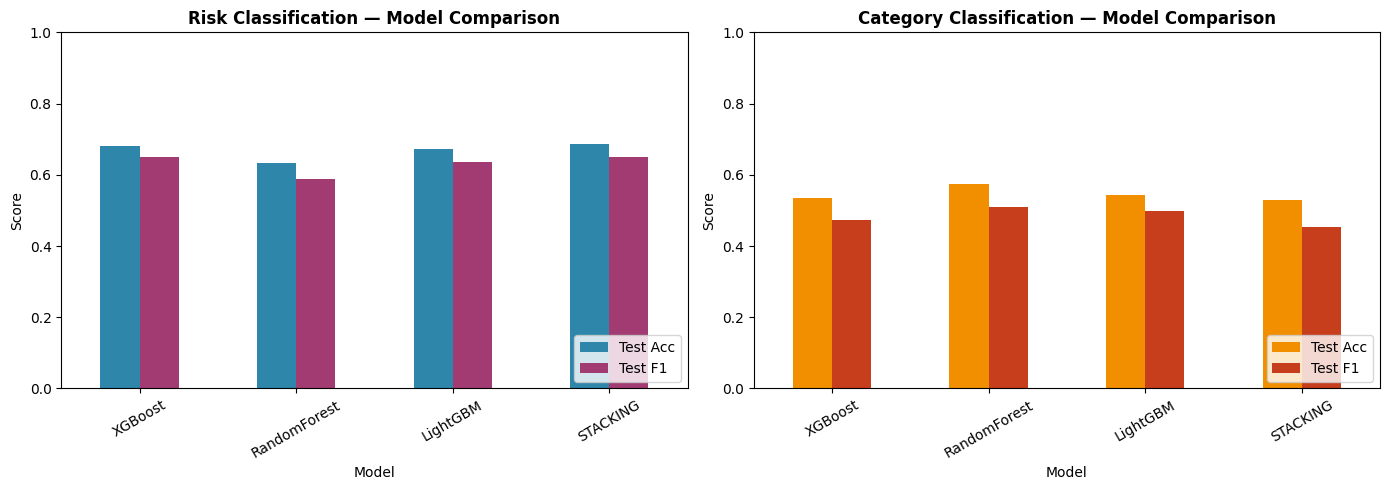

 Saved: model_comparison.png


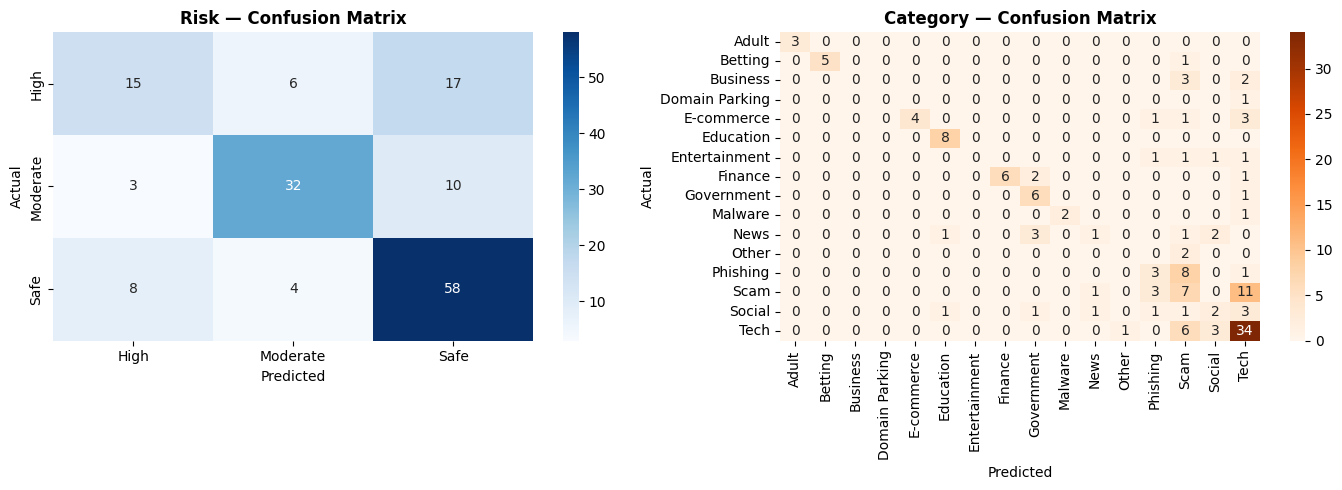

 Saved: confusion_matrices.png


In [ ]:
# CELL 17 — Visualization for Thesis

import matplotlib.pyplot as plt
import seaborn as sns

# ---- 1. Model Comparison Bar Chart ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk comparison
df_risk_comp.plot(x='Model', y=['Test Acc', 'Test F1'], kind='bar', ax=axes[0], color=['#2E86AB', '#A23B72'])
axes[0].set_title('Risk Classification — Model Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=30)

# Category comparison
df_category_comp.plot(x='Model', y=['Test Acc', 'Test F1'], kind='bar', ax=axes[1], color=['#F18F01', '#C73E1D'])
axes[1].set_title('Category Classification — Model Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='lower right')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: model_comparison.png")

# ---- 2. Confusion Matrix Heatmaps ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk confusion matrix
sns.heatmap(cm_risk, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=risk_encoder.classes_,
            yticklabels=risk_encoder.classes_)
axes[0].set_title('Risk — Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Category confusion matrix
sns.heatmap(cm_category, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=category_encoder.classes_,
            yticklabels=category_encoder.classes_)
axes[1].set_title('Category — Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: confusion_matrices.png")

 FEATURE IMPORTANCE ANALYSIS

 Top 20 Most Important Features (Risk):
                          feature  importance
                   text_sbert_254    0.013529
        text_question_count_log1p    0.013069
                   text_sbert_174    0.011743
       text_currency_symbol_count    0.009151
                   text_sbert_008    0.006812
        tp_has_login_related_form    0.006684
                   text_sbert_355    0.006529
text_phone_like_token_count_log1p    0.005880
      html_password_keyword_count    0.005869
                   text_sbert_308    0.005735
                   text_sbert_183    0.005691
                   text_sbert_187    0.005596
                   text_sbert_298    0.005552
                   text_sbert_039    0.005455
                   text_sbert_261    0.005380
                   text_sbert_343    0.005302
                   text_sbert_162    0.005302
             html_has_description    0.005043
                   text_sbert_189    0.004890
          

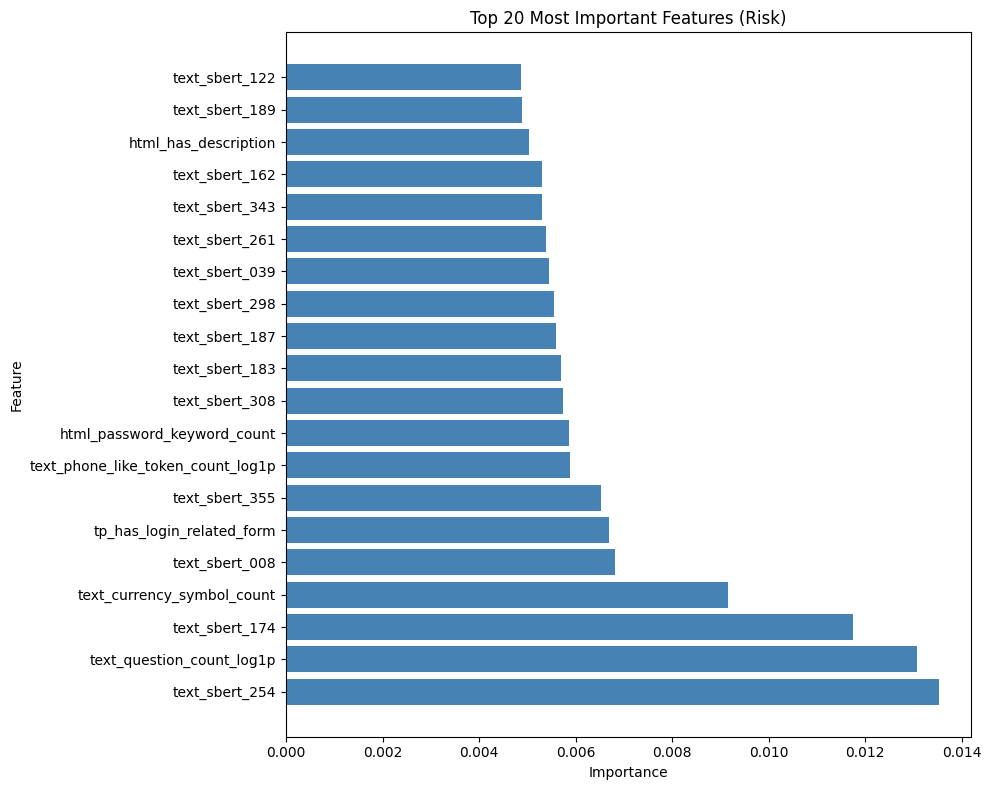

In [ ]:
# CELL 18 — Feature Importance Analysis

print("=" * 70)
print(" FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# Get feature importances from XGBoost (risk)
xgb_risk_model = risk_results['XGBoost']['model']
importances = xgb_risk_model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n Top 20 Most Important Features (Risk):")
print(importance_df.head(20).to_string(index=False))

# Save
importance_df.to_csv(OUTPUT_PATH / 'feature_importance.csv', index=False)

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 8))
top_20 = importance_df.head(20)
ax.barh(range(len(top_20)), top_20['importance'].values, color='steelblue')
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'].values)
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
ax.set_title('Top 20 Most Important Features (Risk)')
plt.tight_layout()